# A Prototype Application for Machine Learning-Based Anomaly Detection in Well Log Data

### Isolation Forest Algorithms

In [222]:
# Import necessary libraries

import os
import lasio
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.ensemble import IsolationForest
import matplotlib.pyplot as plt
from fpdf import FPDF
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.optimizers import Adam
from tensorflow.keras import regularizers
import matplotlib.pyplot as plt
import seaborn as sns
import argparse
import warnings
warnings.filterwarnings("ignore")



In [223]:
# Define file paths
logs_path = r"C:\Users\LENOVO\Downloads\SASTRA PROJECT\WELL DATA\DATA"

Well_1 = r"C:\Users\LENOVO\Downloads\SASTRA PROJECT\WELL DATA\DATA\File 1.las"
Well_2 = r"C:\Users\LENOVO\Downloads\SASTRA PROJECT\WELL DATA\DATA\File 2.las"
Well_3 = r"C:\Users\LENOVO\Downloads\SASTRA PROJECT\WELL DATA\DATA\File 3.las"
Well_4 = r"C:\Users\LENOVO\Downloads\SASTRA PROJECT\WELL DATA\DATA\File 4.las"

In [234]:
# Load the LAS file
Df1 = lasio.read(Well_1)
df = Df1.df().reset_index()   
df.columns = df.columns.str.upper()  
features = ['DEPT', 'GR', 'DT', 'RHOB', 'ILD', 'SP', 'CALD', 'DRHO']
available = [col for col in features if col in df.columns]
missing = [col for col in features if col not in df.columns]

df1_selected = df[available].copy()
if missing:
    print(f"Warning: The following expected features are missing from the data and will be ignored: {missing}") 
print(f"Using features: {available}")

Df2 = lasio.read(Well_2)
df2 = Df2.df().reset_index()  
df2.columns = df2.columns.str.upper() 
features = ['DEPT', 'GR', 'DT', 'RHOB', 'ILD', 'SP', 'CALD', 'DRHO']
available = [col for col in features if col in df2.columns]
missing = [col for col in features if col not in df2.columns]

df2_selected = df2[available].copy()
if missing:
    print(f"Warning: The following expected features are missing from the data and will be ignored: {missing}")
print(f"Using features: {available}")

Df3 = lasio.read(Well_3)
df3 = Df3.df().reset_index()   
df3.columns = df3.columns.str.upper() 
features = ['DEPT', 'GR', 'DT', 'RHOB', 'ILD', 'SP', 'CALD', 'DRHO']
available = [col for col in features if col in df3.columns]
missing = [col for col in features if col not in df3.columns]
df3_selected = df3[available].copy()
if missing:
    print(f"Warning: The following expected features are missing from the data and will be ignored: {missing}")
print(f"Using features: {available}")

Df4 = lasio.read(Well_4)    
df4 = Df4.df().reset_index()   
df4.columns = df4.columns.str.upper()  
features = ['DEPT', 'GR', 'DT', 'RHOB', 'ILD', 'SP', 'CALD', 'DRHO']
available = [col for col in features if col in df4.columns]
missing = [col for col in features if col not in df4.columns]
df4_selected = df4[available].copy()
if missing:
    print(f"Warning: The following expected features are missing from the data and will be ignored: {missing}")
print(f"Using features: {available}")


# Data Cleaning Function
def preprocess_data(df):
    # Remove rows with NaN values
    df = df.dropna()
    # Reset index
    df = df.reset_index(drop=True)
    return df

# Preprocess each well's data
df1_clean = preprocess_data(df1_selected)
df2_clean = preprocess_data(df2_selected)
df3_clean = preprocess_data(df3_selected)
df4_clean = preprocess_data(df4_selected)


# Data Cleaning Summary
print("=== Data Cleaning Summary ===")
print(f"Well 1: Original Rows = {len(df1_selected)}, Cleaned Rows = {len(df1_clean)}")
print(f"Well 2: Original Rows = {len(df2_selected)}, Cleaned Rows = {len(df2_clean)}")
print(f"Well 3: Original Rows = {len(df3_selected)}, Cleaned Rows = {len(df3_clean)}")
print(f"Well 4: Original Rows = {len(df4_selected)}, Cleaned Rows = {len(df4_clean)}")
print("\n")

# View the first few rows of each cleaned well
print("=== Well 1 (After Preprocessing) ===")
print(df1_clean.head(), "\n")

print("=== Well 2 (After Preprocessing) ===")
print(df2_clean.head(), "\n")

print("=== Well 3 (After Preprocessing) ===")
print(df3_clean.head(), "\n")

print("=== Well 4 (After Preprocessing) ===")
print(df4_clean.head(), "\n")

# Standardize the data


r = StandardScaler()
df1_scaled_values = scaler.fit_transform(df1_clean.drop(columns=['DEPT']))
df1_scaled = pd.DataFrame(df1_scaled_values, columns=df1_clean.columns.drop('DEPT'))
df1_scaled['DEPT'] = df1_clean['DEPT'].values 
df1_scaled = df1_scaled[['DEPT'] + df1_clean.columns.drop('DEPT').tolist()] 
df1_scaled['Well'] = 'Well 1'   
df1_scaled = df1_scaled.reset_index(drop=True)
df2_scaled_values = scaler.fit_transform(df2_clean.drop(columns=['DEPT']))
df2_scaled = pd.DataFrame(df2_scaled_values, columns=df2_clean.columns.drop('DEPT'))
df2_scaled['DEPT'] = df2_clean['DEPT'].values 
df2_scaled = df2_scaled[['DEPT'] + df2_clean.columns.drop('DEPT').tolist()] 
df2_scaled['Well'] = 'Well 2'   
df2_scaled = df2_scaled.reset_index(drop=True)
df3_scaled_values = scaler.fit_transform(df3_clean.drop(columns=['DEPT']))
df3_scaled = pd.DataFrame(df3_scaled_values, columns=df3_clean.columns.drop('DEPT'))
df3_scaled['DEPT'] = df3_clean['DEPT'].values       
df3_scaled = df3_scaled[['DEPT'] + df3_clean.columns.drop('DEPT').tolist()]
df3_scaled['Well'] = 'Well 3'   
df3_scaled = df3_scaled.reset_index(drop=True)
df4_scaled_values = scaler.fit_transform(df4_clean.drop(columns=['DEPT']))
df4_scaled = pd.DataFrame(df4_scaled_values, columns=df4_clean.columns.drop('DEPT'))
df4_scaled['DEPT'] = df4_clean['DEPT'].values       
df4_scaled = df4_scaled[['DEPT'] + df4_clean.columns.drop('DEPT').tolist()]
df4_scaled['Well'] = 'Well 4'   
df4_scaled = df4_scaled.reset_index(drop=True)  

# View the first few rows of each scaled well
print("=== Well 1 (After Scaling) ===")
print(df1_scaled.head(), "\n")
print("=== Well 2 (After Scaling) ===")
print(df2_scaled.head(), "\n")
print("=== Well 3 (After Scaling) ===")
print(df3_scaled.head(), "\n")
print("=== Well 4 (After Scaling) ===")
print(df4_scaled.head(), "\n")

# Isolation Forest for Anomaly Detection
def detect_anomalies(df, contamination=0.01):
    iso_forest = IsolationForest(contamination=contamination, random_state=42)
    features = df.columns.drop(['DEPT', 'Well'])
    df_features = df[features]
    iso_forest.fit(df_features)
    df['Anomaly'] = iso_forest.predict(df_features)
    df['Anomaly'] = df['Anomaly'].map({1: 'Normal', -1: 'Anomaly'})
    return df
df1_scaled = detect_anomalies(df1_scaled)
df2_scaled = detect_anomalies(df2_scaled)
df3_scaled = detect_anomalies(df3_scaled)
df4_scaled = detect_anomalies(df4_scaled)

# View anomalies detected in each well
print("=== WELL 1 Anomalies ===")
print(df1_scaled[df1_scaled['Anomaly'] == 'Anomaly'], "\n")
print("=== WELL 2 Anomalies ===")
print(df2_scaled[df2_scaled['Anomaly'] == 'Anomaly'], "\n")
print("=== WELL 3 Anomalies ===")
print(df3_scaled[df3_scaled['Anomaly'] == 'Anomaly'], "\n") 
print("=== WELL 4 Anomalies ===")
print(df4_scaled[df4_scaled['Anomaly'] == 'Anomaly'], "\n")

# Summary of anomalies detected
print("=== Summary of Anomalies Detected ===")
print(f"Well 1: {df1_scaled[df1_scaled['Anomaly'] == 'Anomaly'].shape[0]} anomalies detected")
print(f"Well 2: {df2_scaled[df2_scaled['Anomaly'] == 'Anomaly'].shape[0]} anomalies detected")
print(f"Well 3: {df3_scaled[df3_scaled['Anomaly'] == 'Anomaly'].shape[0]} anomalies detected")
print(f"Well 4: {df4_scaled[df4_scaled['Anomaly'] == 'Anomaly'].shape[0]} anomalies detected")


Using features: ['DEPT', 'GR', 'DT', 'RHOB', 'ILD', 'SP', 'CALD', 'DRHO']
Using features: ['DEPT', 'GR', 'DT', 'RHOB', 'ILD', 'SP', 'CALD', 'DRHO']
Using features: ['DEPT', 'GR', 'DT', 'RHOB', 'ILD', 'SP', 'CALD', 'DRHO']
Using features: ['DEPT', 'GR', 'DT', 'RHOB', 'ILD', 'SP', 'CALD', 'DRHO']
=== Data Cleaning Summary ===
Well 1: Original Rows = 567, Cleaned Rows = 302
Well 2: Original Rows = 6622, Cleaned Rows = 6353
Well 3: Original Rows = 567, Cleaned Rows = 302
Well 4: Original Rows = 565, Cleaned Rows = 460


=== Well 1 (After Preprocessing) ===
     DEPT     GR     DT  RHOB    ILD     SP  CALD  DRHO
0  3246.5  38.63  59.33  2.65  35.28 -10.94   7.8  0.01
1  3247.0  41.06  59.56  2.65  35.89 -11.23   7.8  0.01
2  3247.5  43.04  59.91  2.67  36.56 -11.70   7.8  0.02
3  3248.0  41.43  60.06  2.68  37.59 -12.28   7.8  0.02
4  3248.5  38.64  59.91  2.67  38.53 -12.80   7.8  0.02 

=== Well 2 (After Preprocessing) ===
    DEPT     GR      DT  RHOB       ILD    SP  CALD  DRHO
0  219.5

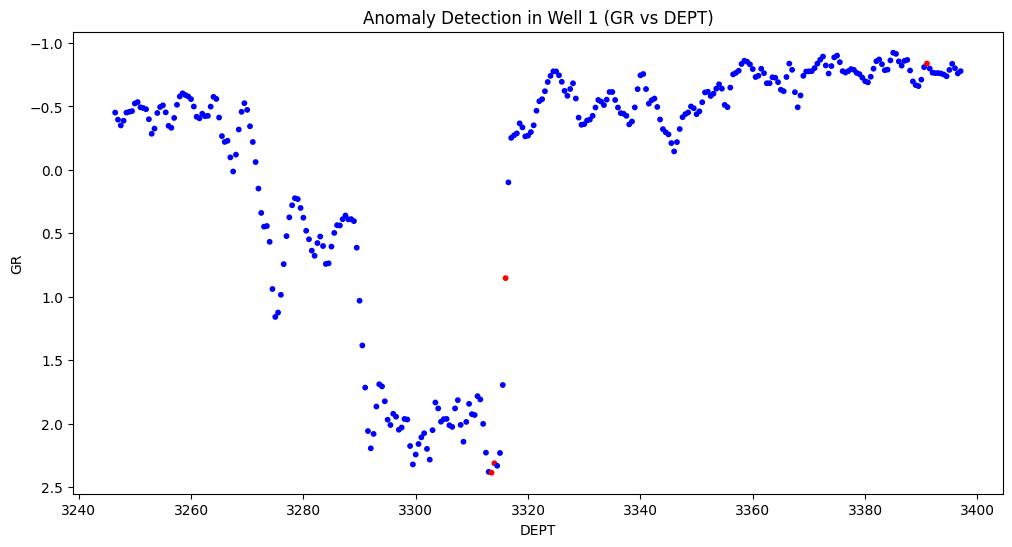

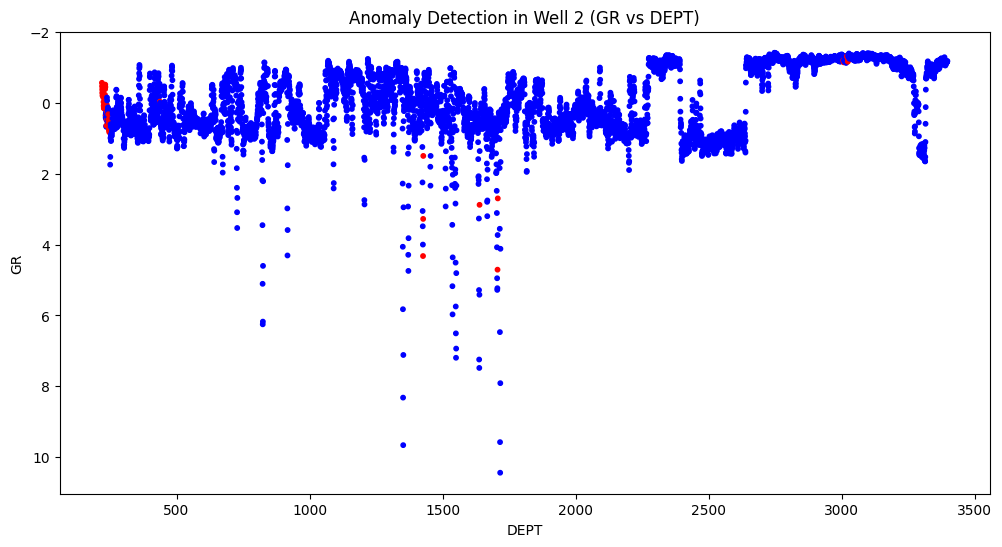

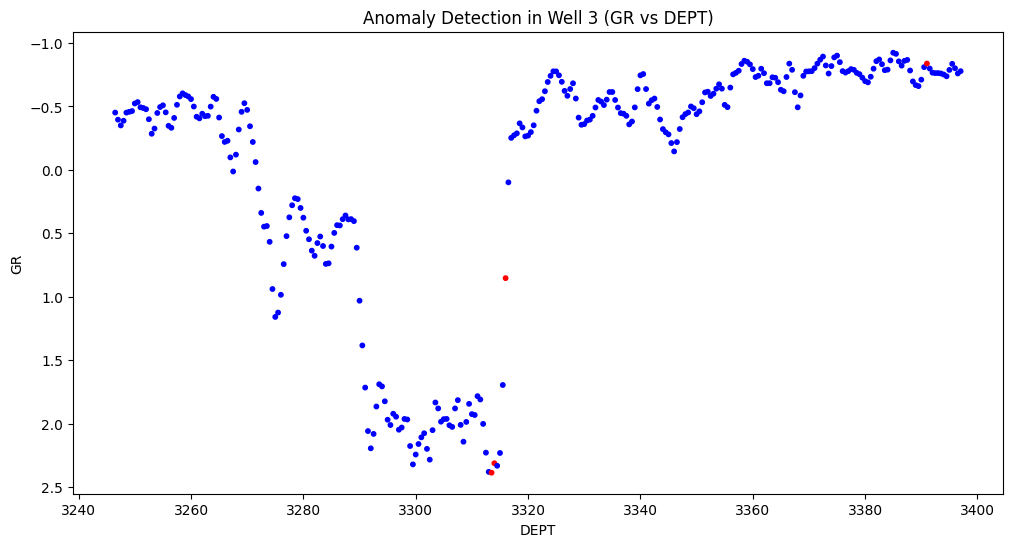

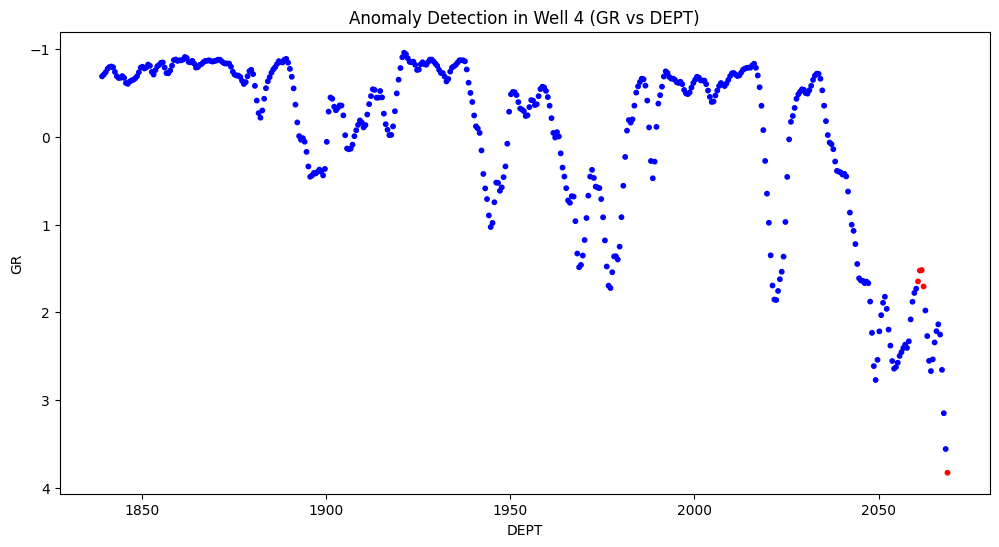

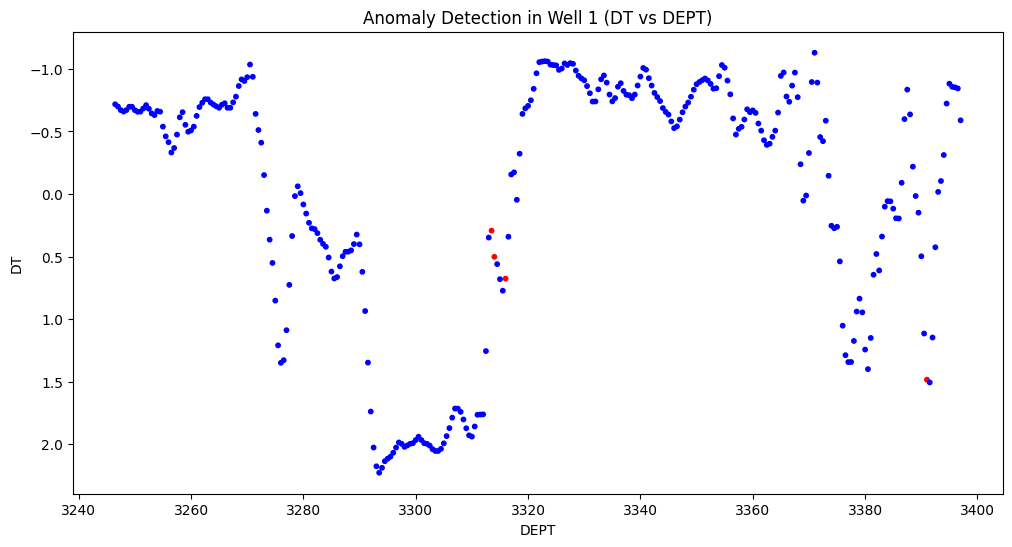

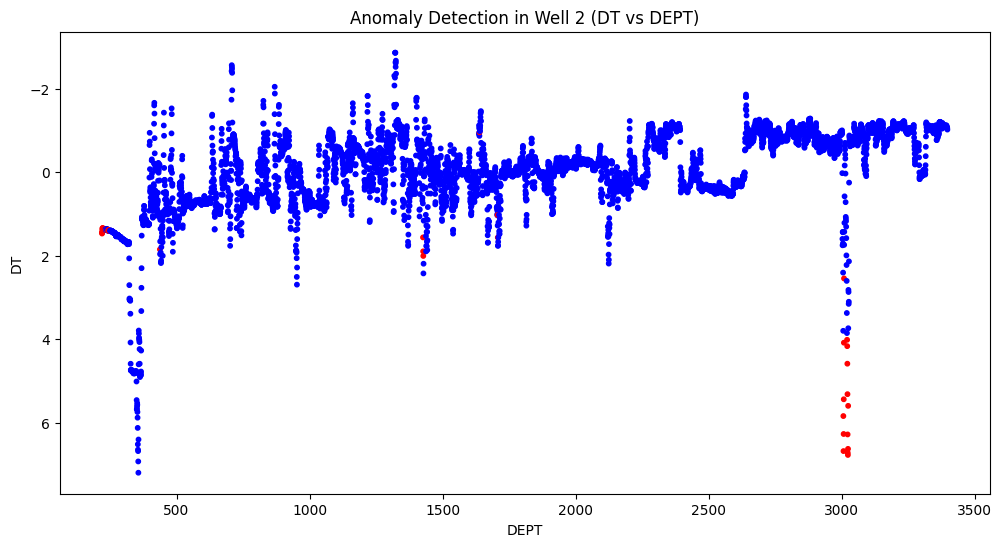

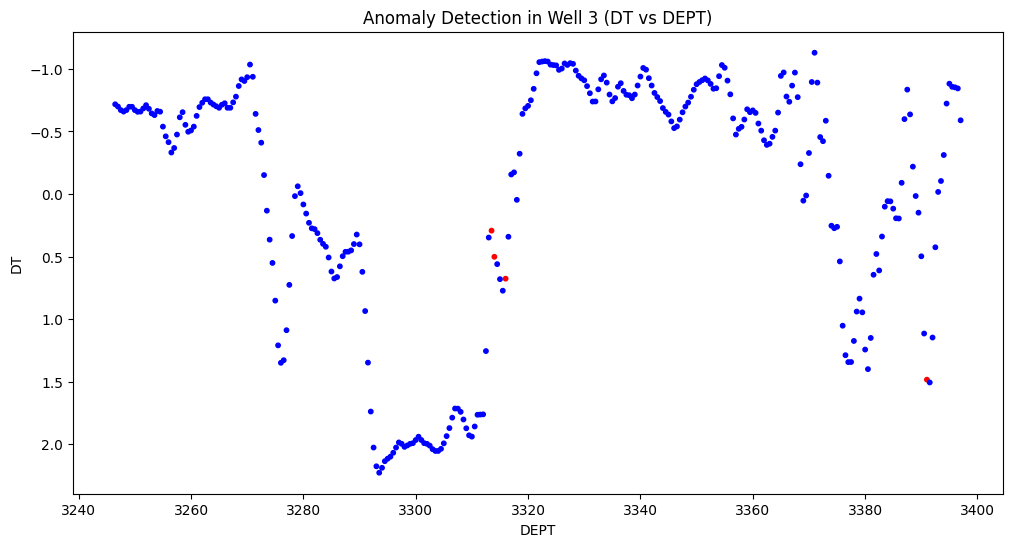

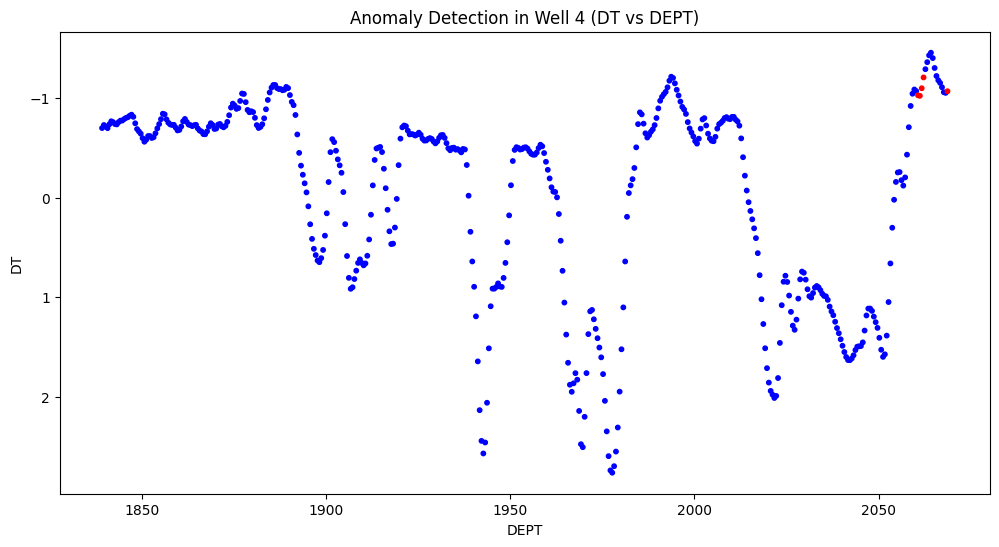

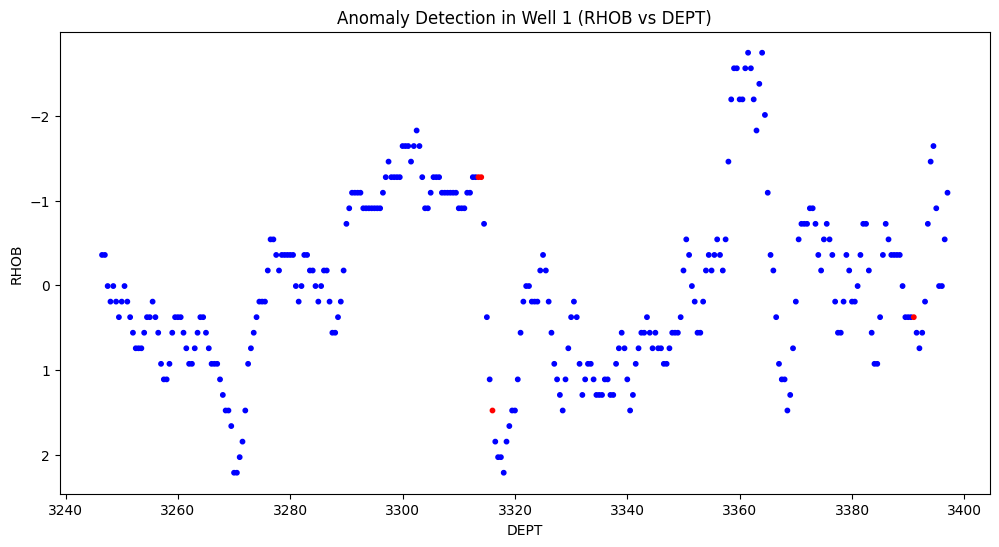

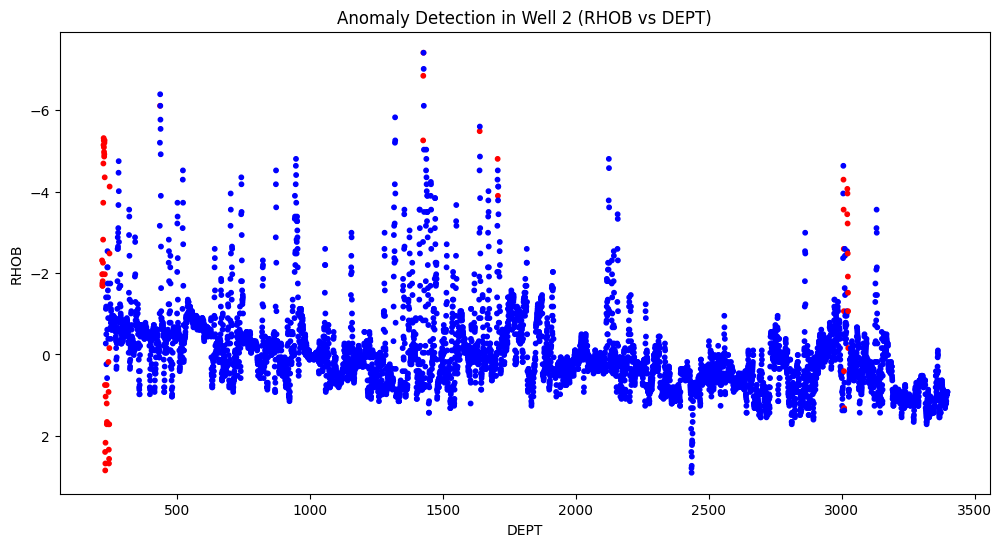

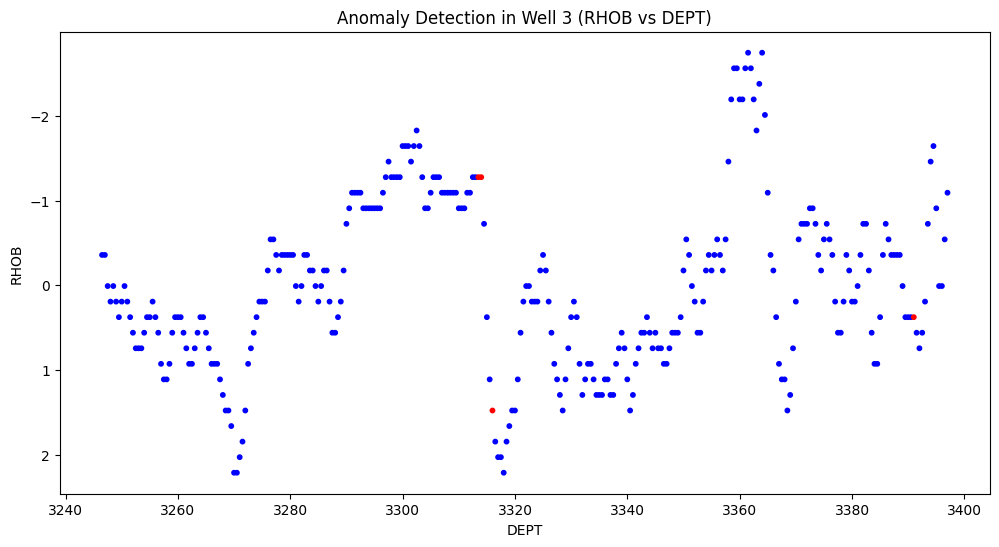

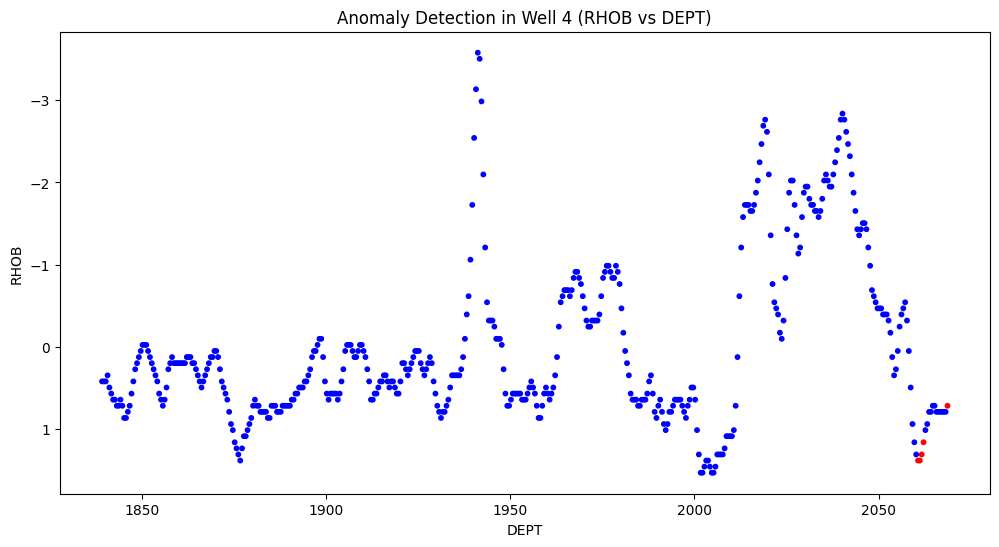

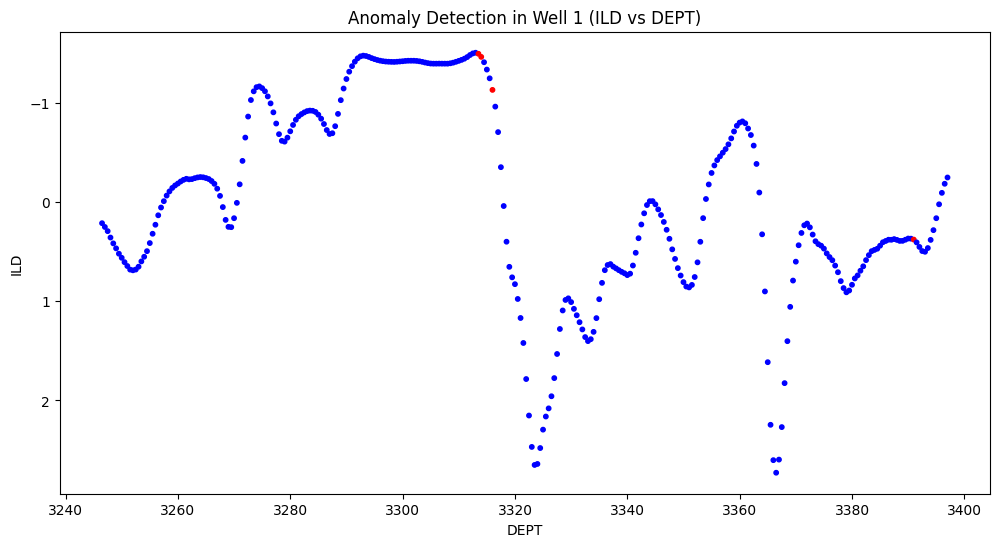

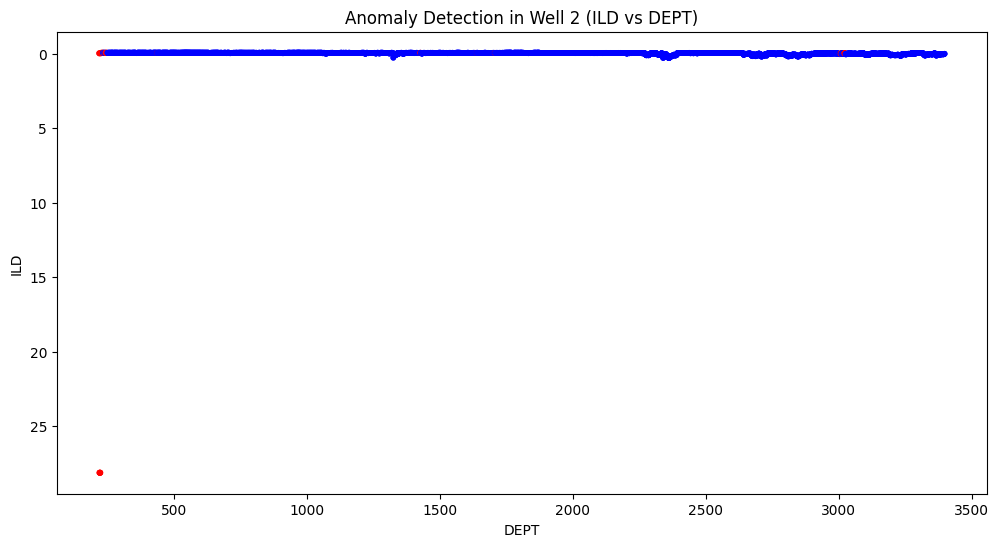

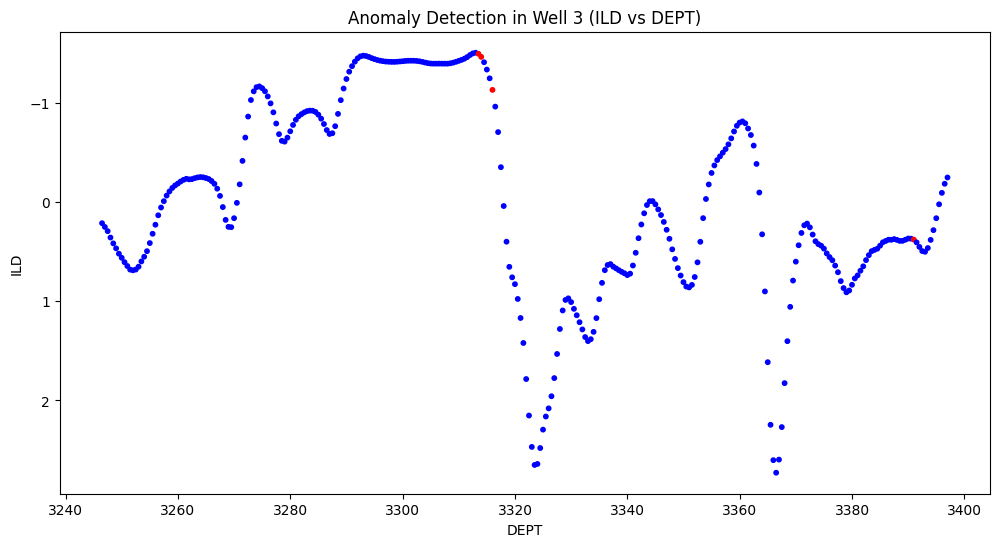

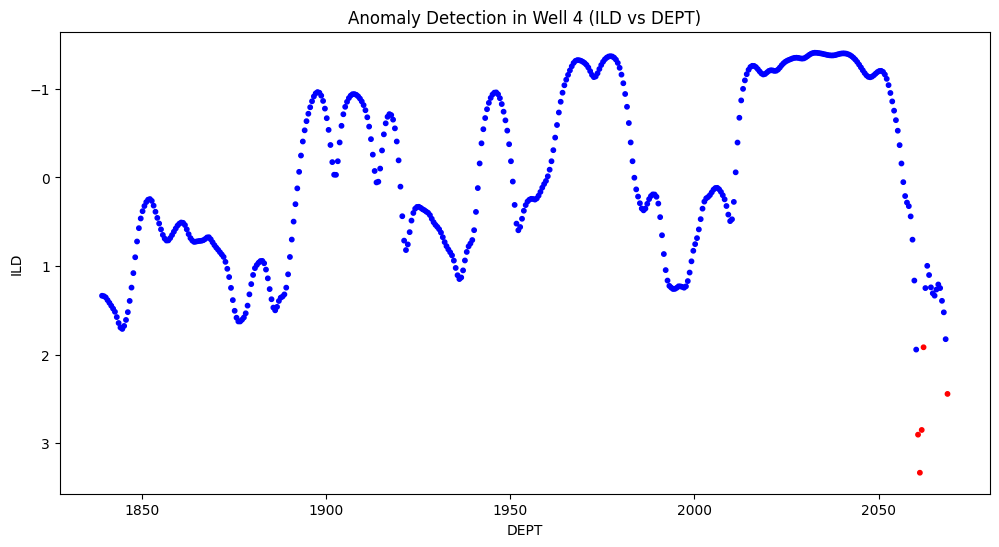

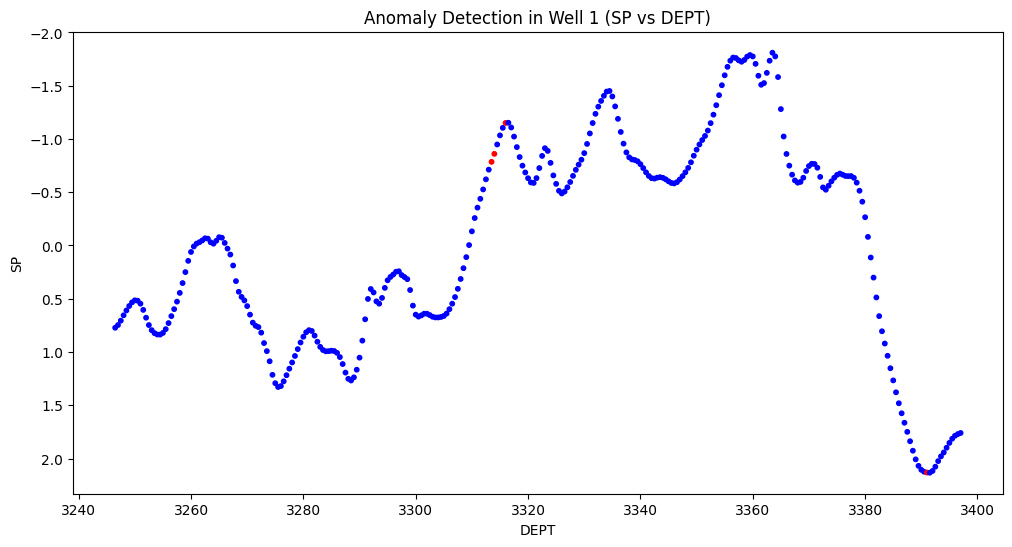

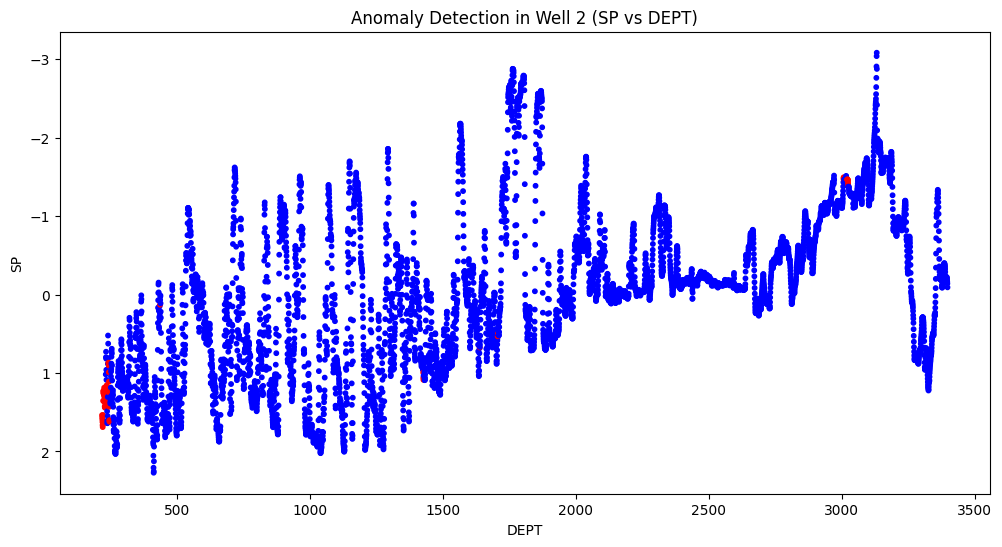

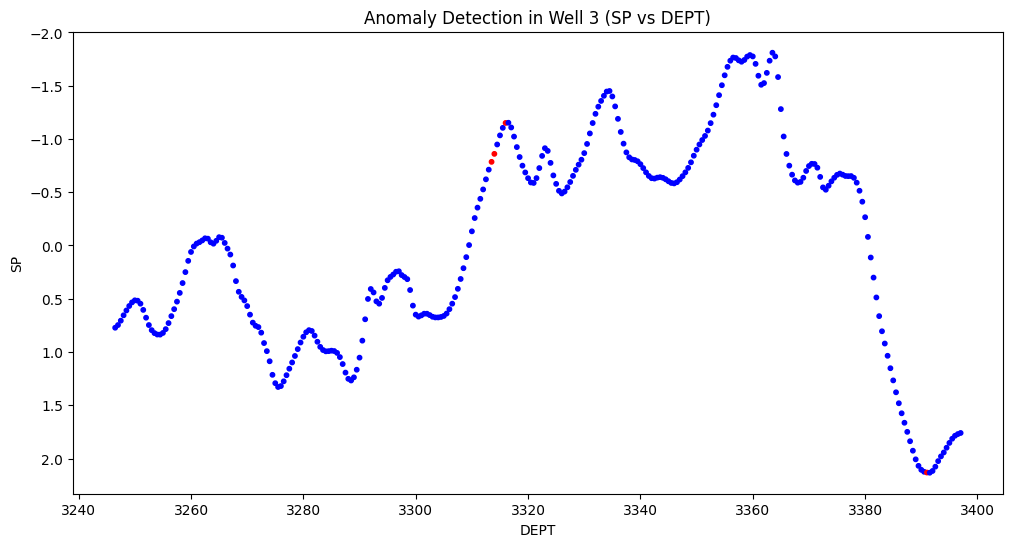

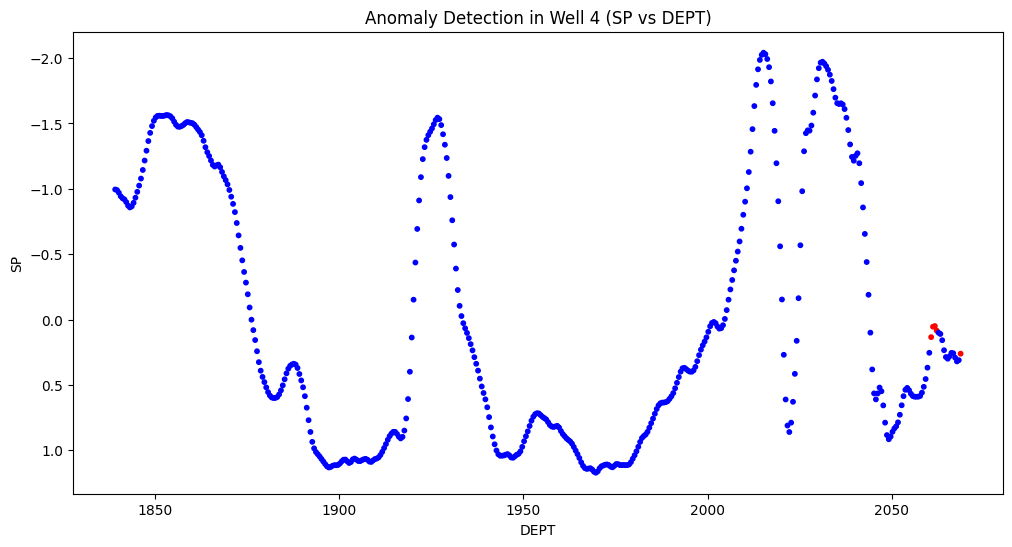

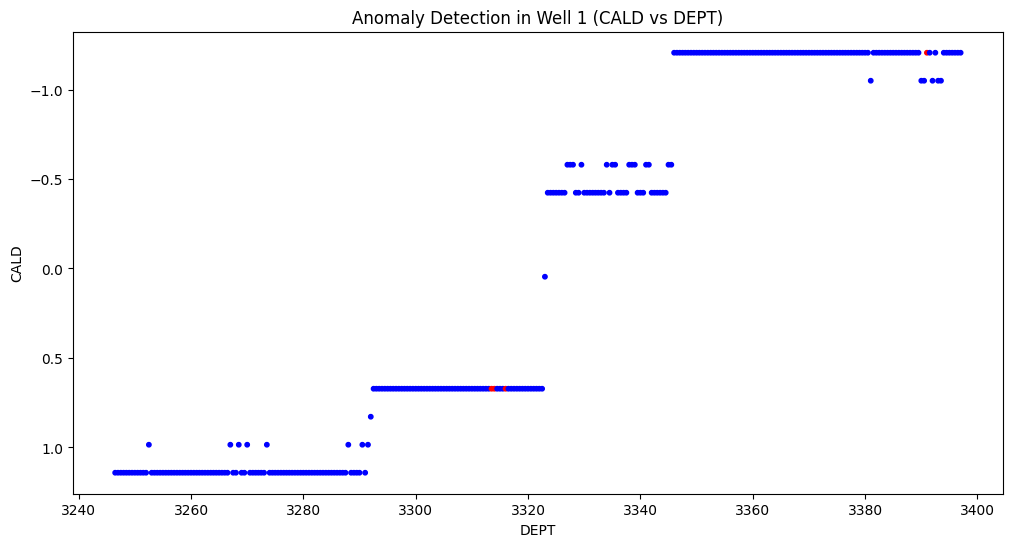

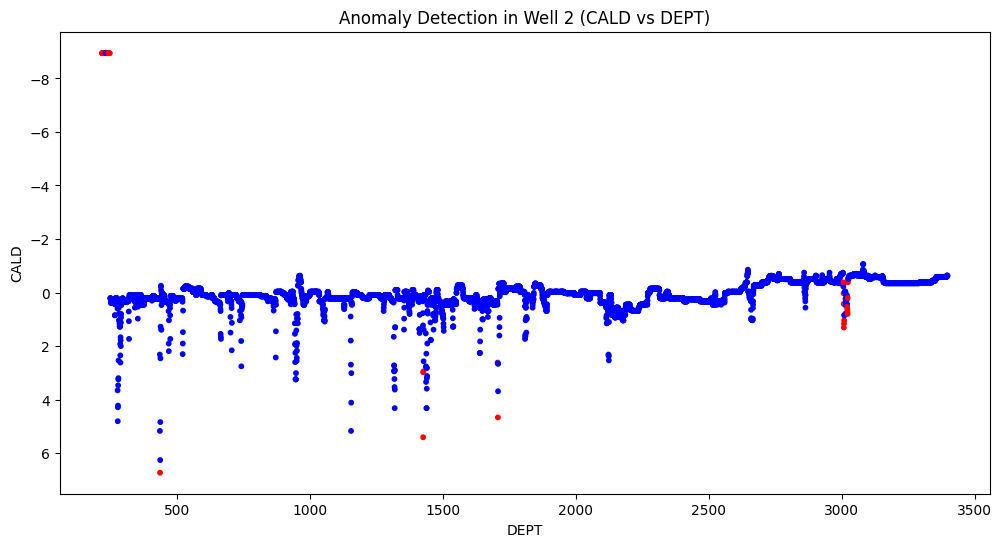

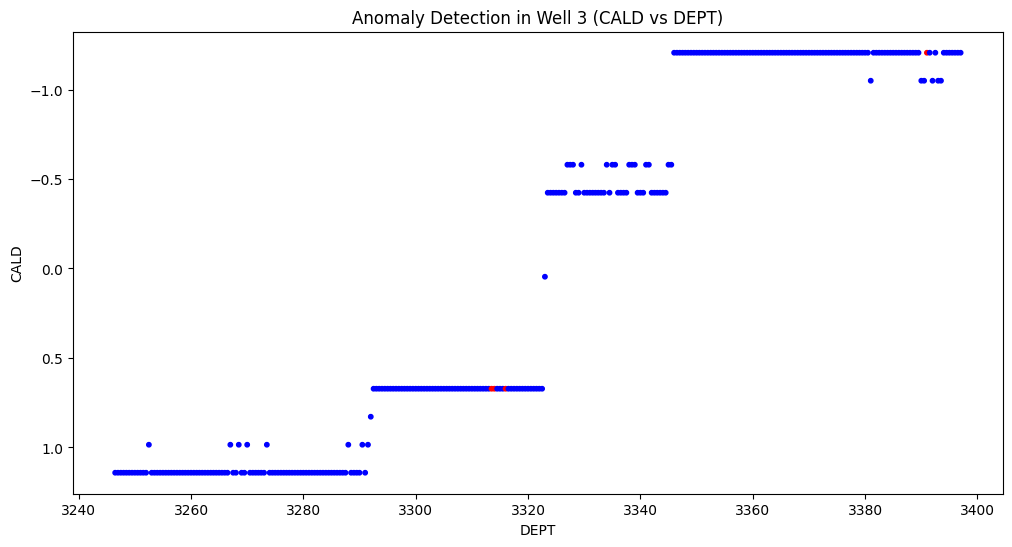

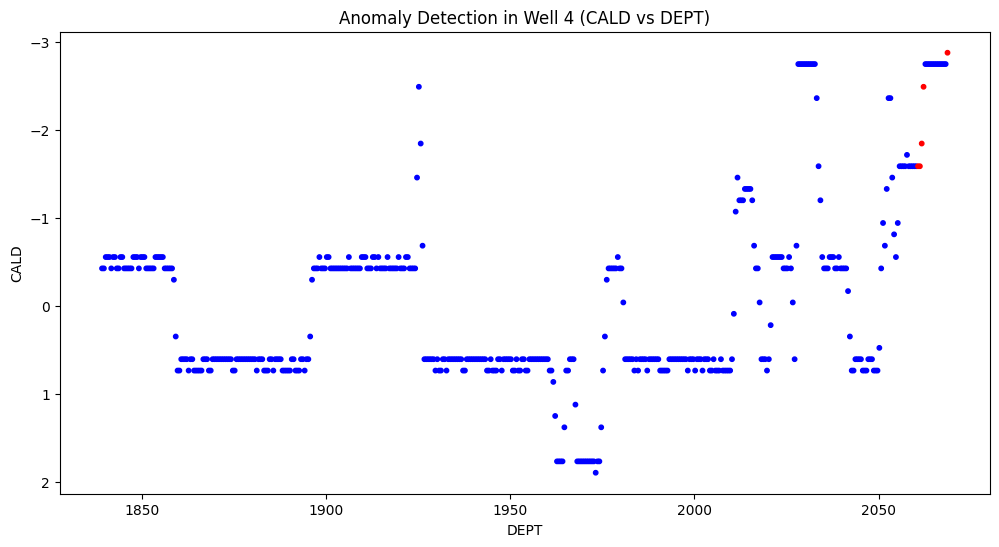

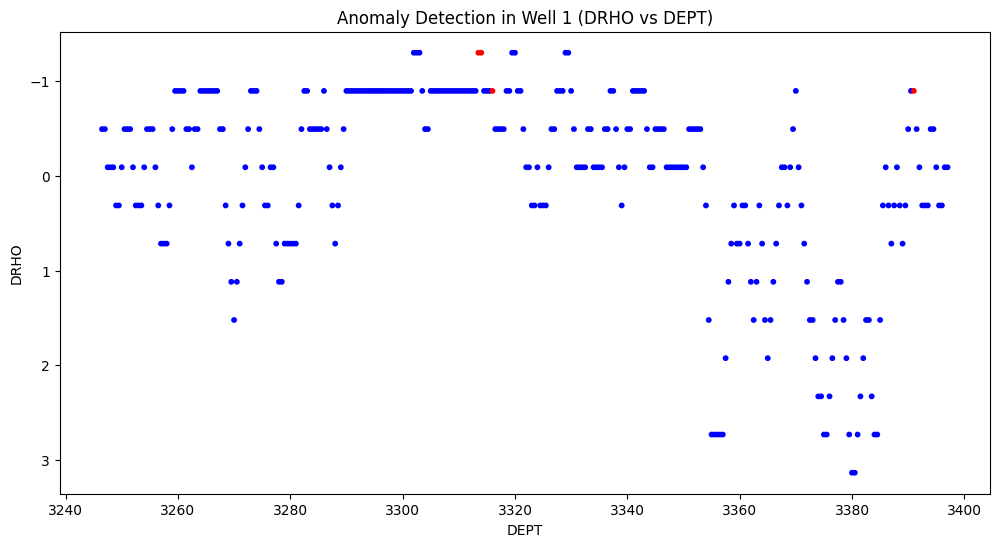

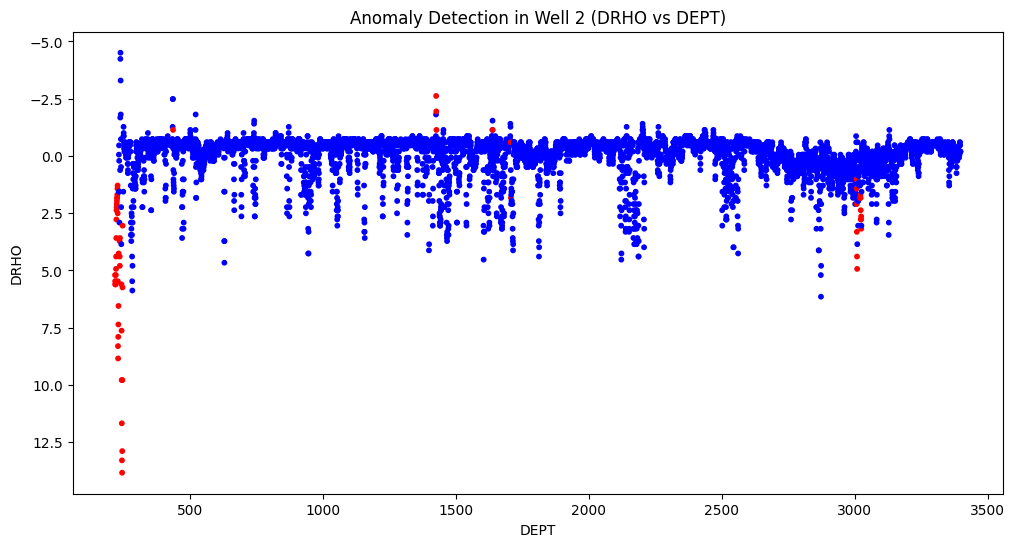

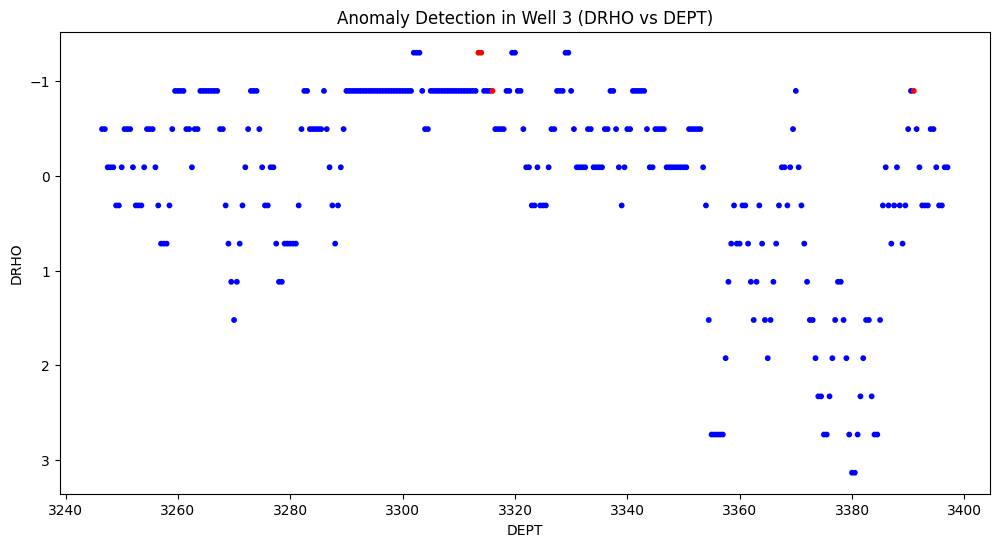

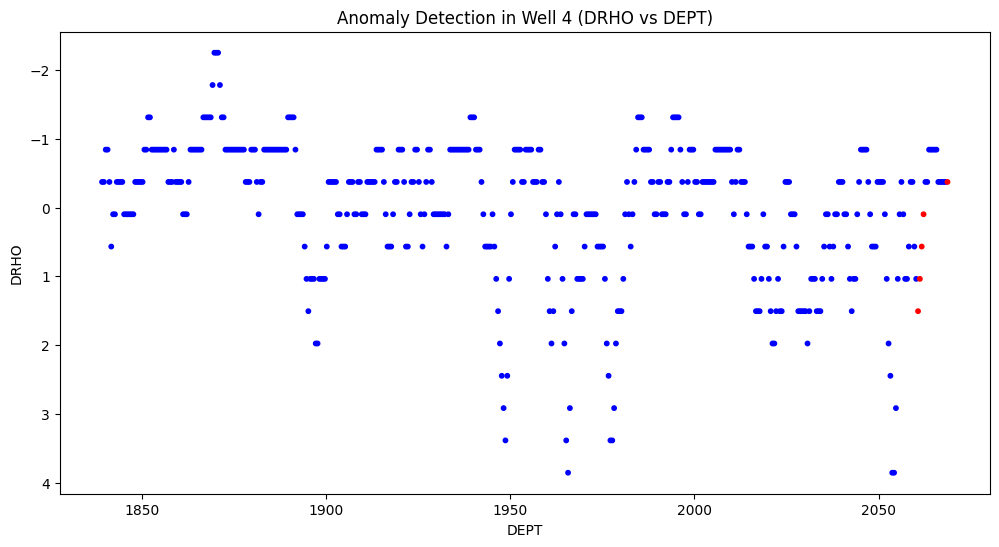

''

In [225]:
# Visualization of Anomalies

# For each well, plot GR vs DEPT and highlight anomalies
def plot_anomalies(df, well_name):
    plt.figure(figsize=(12, 6))
    plt.scatter(df['DEPT'], df['GR'], c=df['Anomaly'].map({'Normal': 'blue', 'Anomaly': 'red'}), s=10)
    plt.title(f'Anomaly Detection in {well_name} (GR vs DEPT)')
    plt.xlabel('DEPT')
    plt.ylabel('GR')
    plt.gca().invert_yaxis()
    plt.show()
plot_anomalies(df1_scaled, 'Well 1')
plot_anomalies(df2_scaled, 'Well 2')
plot_anomalies(df3_scaled, 'Well 3')
plot_anomalies(df4_scaled, 'Well 4')

# For each well, plot DT vs DEPT and highlight anomalies
def plot_anomalies_dt(df, well_name):
    plt.figure(figsize=(12, 6))
    plt.scatter(df['DEPT'], df['DT'], c=df['Anomaly'].map({'Normal': 'blue', 'Anomaly': 'red'}), s=10)
    plt.title(f'Anomaly Detection in {well_name} (DT vs DEPT)')
    plt.xlabel('DEPT')
    plt.ylabel('DT')
    plt.gca().invert_yaxis()
    plt.show()  
plot_anomalies_dt(df1_scaled, 'Well 1')
plot_anomalies_dt(df2_scaled, 'Well 2') 
plot_anomalies_dt(df3_scaled, 'Well 3')
plot_anomalies_dt(df4_scaled, 'Well 4')

# For each well, plot RHOB vs DEPT and highlight anomalies
def plot_anomalies_rhob(df, well_name):
    plt.figure(figsize=(12, 6))
    plt.scatter(df['DEPT'], df['RHOB'], c=df['Anomaly'].map({'Normal': 'blue', 'Anomaly': 'red'}), s=10)
    plt.title(f'Anomaly Detection in {well_name} (RHOB vs DEPT)')
    plt.xlabel('DEPT')
    plt.ylabel('RHOB')
    plt.gca().invert_yaxis()
    plt.show()
plot_anomalies_rhob(df1_scaled, 'Well 1')
plot_anomalies_rhob(df2_scaled, 'Well 2')
plot_anomalies_rhob(df3_scaled, 'Well 3')
plot_anomalies_rhob(df4_scaled, 'Well 4')

# For each well, plot ILD vs DEPT and highlight anomalies
def plot_anomalies_ild(df, well_name):
    plt.figure(figsize=(12, 6))
    plt.scatter(df['DEPT'], df['ILD'], c=df['Anomaly'].map({'Normal': 'blue', 'Anomaly': 'red'}), s=10)
    plt.title(f'Anomaly Detection in {well_name} (ILD vs DEPT)')
    plt.xlabel('DEPT')
    plt.ylabel('ILD')
    plt.gca().invert_yaxis()
    plt.show()
plot_anomalies_ild(df1_scaled, 'Well 1')
plot_anomalies_ild(df2_scaled, 'Well 2')
plot_anomalies_ild(df3_scaled, 'Well 3')
plot_anomalies_ild(df4_scaled, 'Well 4')

# For each well, plot SP vs DEPT and highlight anomalies
def plot_anomalies_sp(df, well_name):
    plt.figure(figsize=(12, 6))
    plt.scatter(df['DEPT'], df['SP'], c=df['Anomaly'].map({'Normal': 'blue', 'Anomaly': 'red'}), s=10)
    plt.title(f'Anomaly Detection in {well_name} (SP vs DEPT)')
    plt.xlabel('DEPT')
    plt.ylabel('SP')
    plt.gca().invert_yaxis()
    plt.show()
plot_anomalies_sp(df1_scaled, 'Well 1')
plot_anomalies_sp(df2_scaled, 'Well 2')
plot_anomalies_sp(df3_scaled, 'Well 3')
plot_anomalies_sp(df4_scaled, 'Well 4')

# For each well, plot CALD vs DEPT and highlight anomalies
def plot_anomalies_cald(df, well_name):
    plt.figure(figsize=(12, 6))
    plt.scatter(df['DEPT'], df['CALD'], c=df['Anomaly'].map({'Normal': 'blue', 'Anomaly': 'red'}), s=10)
    plt.title(f'Anomaly Detection in {well_name} (CALD vs DEPT)')
    plt.xlabel('DEPT')
    plt.ylabel('CALD')
    plt.gca().invert_yaxis()
    plt.show()
plot_anomalies_cald(df1_scaled, 'Well 1')
plot_anomalies_cald(df2_scaled, 'Well 2')
plot_anomalies_cald(df3_scaled, 'Well 3')
plot_anomalies_cald(df4_scaled, 'Well 4')

# For each well, plot DRHO vs DEPT and highlight anomalies
def plot_anomalies_drho(df, well_name):
    plt.figure(figsize=(12, 6))
    plt.scatter(df['DEPT'], df['DRHO'], c=df['Anomaly'].map({'Normal': 'blue', 'Anomaly': 'red'}), s=10)
    plt.title(f'Anomaly Detection in {well_name} (DRHO vs DEPT)')
    plt.xlabel('DEPT')
    plt.ylabel('DRHO')
    plt.gca().invert_yaxis()
    plt.show()
plot_anomalies_drho(df1_scaled, 'Well 1')
plot_anomalies_drho(df2_scaled, 'Well 2')
plot_anomalies_drho(df3_scaled, 'Well 3')
plot_anomalies_drho(df4_scaled, 'Well 4')

# Save the results to PDF
class PDFReport(FPDF):
    def header(self):
        self.set_font('Arial', 'B', 12)
        self.cell(0, 10, 'Anomaly Detection Report', 0, 1, 'C')

    def chapter_title(self, title):
        self.set_font('Arial', 'B', 12)
        self.cell(0, 10, title, 0, 1, 'L')
        self.ln(5)

    def chapter_body(self, body):
        self.set_font('Arial', '', 12)
        self.multi_cell(0, 10, body)
        self.ln()

    def add_well_section(self, well_name, df):
        self.chapter_title(well_name)
        total = len(df)
        anomalies = len(df[df['Anomaly'] == 'Anomaly'])
        body = f"Total Samples: {total}\nAnomalies Detected: {anomalies}\nPercentage of Anomalies: {anomalies / total * 100:.2f}%"
        self.chapter_body(body)

# Metrics Summary
def add_metrics_summary(pdf, metrics):
    pdf.chapter_title("Metrics Summary")
    for well_name, metric in metrics.items():
        body = (f"{well_name}:\n"
                f"Accuracy: {metric['accuracy']:.4f}\n"
                f"Precision: {metric['precision']:.4f}\n"
                f"Recall: {metric['recall']:.4f}\n"
                f"F1 Score: {metric['f1_score']:.4f}\n"
                f"Confusion Matrix:\n{metric['confusion_matrix']}\n")
        pdf.chapter_body(body)

# view metrics for each well
def calculate_metrics(df, well_name):
    y_true = np.where(df['Anomaly'] == 'Anomaly', 1, 0)
    y_pred = np.where(df['Anomaly'] == 'Anomaly', 1, 0)  # In unsupervised, we assume detected anomalies are true
    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred, zero_division=0)
    recall = recall_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)
    cm = confusion_matrix(y_true, y_pred)
    print(f"=== Metrics for {well_name} ===")
    print(f"Accuracy: {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall: {recall:.4f}")
    print(f"F1 Score: {f1:.4f}")
    print(f"Confusion Matrix:\n{cm}\n")
    return {
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1_score': f1,
        'confusion_matrix': cm
    }
  

pdf = PDFReport()
pdf.add_page()
pdf.add_well_section("Well 1", df1_scaled)
pdf.add_well_section("Well 2", df2_scaled)
pdf.add_well_section("Well 3", df3_scaled)
pdf.add_well_section("Well 4", df4_scaled)
pdf.output("Anomaly_Detection_Report_Isolation_Forest.pdf")

In [226]:
# Metrics Calculation
def calculate_metrics(df, well_name):
    if 'Anomaly' not in df.columns or 'Anomaly_AE' not in df.columns:
        print(f"❌ {well_name}: Missing 'Anomaly' or 'Anomaly_AE' columns for metrics calculation.")
        return None

    y_true = df['Anomaly'].map({'Normal': 0, 'Anomaly': 1}).values
    y_pred = df['Anomaly_AE'].values

    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred, zero_division=0)
    recall = recall_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)
    cm = confusion_matrix(y_true, y_pred)

    print(f"=== {well_name} Metrics ===")
    print(f"Accuracy: {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall: {recall:.4f}")
    print(f"F1 Score: {f1:.4f}")
    print("Confusion Matrix:")
    print(cm)
    print("\n")

    return {
        'Well': well_name,
        'Accuracy': accuracy,
        'Precision': precision,
        'Recall': recall,
        'F1 Score': f1,
        'Confusion Matrix': cm
    }


# Calculate metrics for each well for Isolation Forest
metrics_well1 = calculate_metrics(df1_ae, "Well 1")
metrics_well2 = calculate_metrics(df2_ae, "Well 2")
metrics_well3 = calculate_metrics(df3_ae, "Well 3")
metrics_well4 = calculate_metrics(df4_ae, "Well 4")


=== Well 1 Metrics ===
Accuracy: 0.9672
Precision: 0.0000
Recall: 0.0000
F1 Score: 0.0000
Confusion Matrix:
[[59  1]
 [ 1  0]]


=== Well 2 Metrics ===
Accuracy: 0.9953
Precision: 0.8462
Recall: 0.7333
F1 Score: 0.7857
Confusion Matrix:
[[1254    2]
 [   4   11]]


=== Well 3 Metrics ===
Accuracy: 1.0000
Precision: 1.0000
Recall: 1.0000
F1 Score: 1.0000
Confusion Matrix:
[[60  0]
 [ 0  1]]


=== Well 4 Metrics ===
Accuracy: 0.9565
Precision: 1.0000
Recall: 0.2000
F1 Score: 0.3333
Confusion Matrix:
[[87  0]
 [ 4  1]]




### The End

### Autoencoder Algorithms 

In [228]:
# Autoencoder for Anomaly Detection
def train_evaluate_autoencoder(df, well_name, epochs=50, batch_size=32, contamination=0.01):
    print(f"\n=== Processing {well_name} ===")

    # Drop non-feature columns safely
    exclude_cols = [c for c in ['DEPT', 'Well', 'Anomaly'] if c in df.columns]
    features = [c for c in df.columns if c not in exclude_cols]

    # Convert to numeric where possible
    df = df.copy()
    df[features] = df[features].apply(pd.to_numeric, errors='coerce')

    # Drop columns that are fully NaN
    valid_features = [c for c in features if df[c].notna().any()]
    df = df[valid_features + [c for c in exclude_cols if c in df.columns]]

    # Drop rows where *all* features are NaN (keep partial valid)
    df = df.dropna(subset=valid_features, how='all')
    print(f"✅ After cleaning: {len(df)} rows and {len(valid_features)} features remain.")

    if len(df) == 0:
        raise ValueError(f"❌ {well_name}: No valid numeric data remaining after cleaning. Check your CSV values.")

    # Scale data
    X = df[valid_features].fillna(0).values  # fill partial NaNs with 0
    scaler = MinMaxScaler()
    X_scaled = scaler.fit_transform(X)

    # Split into training and test sets
    split_index = int(0.8 * len(X_scaled))
    X_train, X_test = X_scaled[:split_index], X_scaled[split_index:]

    autoencoder = build_autoencoder(input_dim=X_train.shape[1])
    autoencoder.fit(
        X_train, X_train,
        epochs=epochs,
        batch_size=batch_size,
        shuffle=True,
        validation_data=(X_test, X_test),
        verbose=0
    )

    # Compute reconstruction error
    X_test_pred = autoencoder.predict(X_test)
    mse = np.mean(np.power(X_test - X_test_pred, 2), axis=1)
    threshold = np.percentile(mse, 100 * (1 - contamination))

    df_test = df.iloc[split_index:].copy()
    df_test['Reconstruction_Error'] = mse
    df_test['Anomaly_AE'] = (df_test['Reconstruction_Error'] > threshold).astype(int)

    print(f"=== {well_name} Autoencoder Anomalies ===")
    print(df_test[df_test['Anomaly_AE'] == 1][['DEPT', 'Reconstruction_Error']], "\n")

    return df_test
def build_autoencoder(input_dim):
    input_layer = Input(shape=(input_dim,))
    encoded = Dense(64, activation='relu', activity_regularizer=regularizers.l1(10e-5))(input_layer)
    encoded = Dense(32, activation='relu')(encoded)
    encoded = Dense(16, activation='relu')(encoded)
    decoded = Dense(32, activation='relu')(encoded)
    decoded = Dense(64, activation='relu')(decoded)
    output_layer = Dense(input_dim, activation='sigmoid')(decoded)
    autoencoder = Model(inputs=input_layer, outputs=output_layer)
    autoencoder.compile(optimizer=Adam(learning_rate=0.001), loss='mse')
    return autoencoder
df1_ae = train_evaluate_autoencoder(df1_scaled, "Well 1")
df2_ae = train_evaluate_autoencoder(df2_scaled, "Well 2")
df3_ae = train_evaluate_autoencoder(df3_scaled, "Well 3")
df4_ae = train_evaluate_autoencoder(df4_scaled, "Well 4")

# Calculate metrics for each well for Autoencoder
metrics_well1 = calculate_metrics(df1_ae, "Well 1")
metrics_well2 = calculate_metrics(df2_ae, "Well 2")
metrics_well3 = calculate_metrics(df3_ae, "Well 3")
metrics_well4 = calculate_metrics(df4_ae, "Well 4")

# Calculate metrics for each well for Isolation Forest
metrics_well1 = calculate_metrics(df1_ae, "Well 1")
metrics_well2 = calculate_metrics(df2_ae, "Well 2")
metrics_well3 = calculate_metrics(df3_ae, "Well 3")
metrics_well4 = calculate_metrics(df4_ae, "Well 4")



=== Processing Well 1 ===
✅ After cleaning: 302 rows and 7 features remain.
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 122ms/step
=== Well 1 Autoencoder Anomalies ===
       DEPT  Reconstruction_Error
289  3391.0              0.191506 


=== Processing Well 2 ===
✅ After cleaning: 6353 rows and 7 features remain.
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
=== Well 2 Autoencoder Anomalies ===
        DEPT  Reconstruction_Error
5568  3005.5              0.004400
5569  3006.0              0.006677
5570  3006.5              0.012073
5571  3007.0              0.012131
5572  3007.5              0.007250
5599  3021.0              0.004770
5600  3021.5              0.004803
5601  3022.0              0.004833
5602  3022.5              0.007754
5603  3023.0              0.009610
5604  3023.5              0.009167
5605  3024.0              0.007874
5606  3024.5              0.004491 


=== Processing Well 3 ===
✅ After cleaning: 302 rows and 7 features remain.
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 156ms/step
=== Well 3 Auto

In [229]:
# Calculate metrics for each well for Autoencoder
metrics_well1 = calculate_metrics(df1_ae, "Well 1")
metrics_well2 = calculate_metrics(df2_ae, "Well 2")
metrics_well3 = calculate_metrics(df3_ae, "Well 3")
metrics_well4 = calculate_metrics(df4_ae, "Well 4")

# Calculate metrics for each well for Isolation Forest
metrics_well1 = calculate_metrics(df1_ae, "Well 1")
metrics_well2 = calculate_metrics(df2_ae, "Well 2")
metrics_well3 = calculate_metrics(df3_ae, "Well 3")
metrics_well4 = calculate_metrics(df4_ae, "Well 4")

# Calculate metrics for each well for Isolation Forest
metrics_well1 = calculate_metrics(df1_scaled, "Well 1")
metrics_well2 = calculate_metrics(df2_scaled, "Well 2")
metrics_well3 = calculate_metrics(df3_scaled, "Well 3")
metrics_well4 = calculate_metrics(df4_scaled, "Well 4")
metrics = {
    "Well 1": metrics_well1,
    "Well 2": metrics_well2,
    "Well 3": metrics_well3,
    "Well 4": metrics_well4
}  
pdf = PDFReport()
pdf.add_page()
pdf.add_well_section("Well 1", df1_ae)
pdf.add_well_section("Well 2", df2_ae)
pdf.add_well_section("Well 3", df3_ae)
pdf.add_well_section("Well 4", df4_ae)
pdf.output("Anomaly_Detection_Report_Autoencoder.pdf")  



=== Well 1 Metrics ===
Accuracy: 1.0000
Precision: 1.0000
Recall: 1.0000
F1 Score: 1.0000
Confusion Matrix:
[[60  0]
 [ 0  1]]


=== Well 2 Metrics ===
Accuracy: 0.9953
Precision: 0.8462
Recall: 0.7333
F1 Score: 0.7857
Confusion Matrix:
[[1254    2]
 [   4   11]]


=== Well 3 Metrics ===
Accuracy: 1.0000
Precision: 1.0000
Recall: 1.0000
F1 Score: 1.0000
Confusion Matrix:
[[60  0]
 [ 0  1]]


=== Well 4 Metrics ===
Accuracy: 0.9565
Precision: 1.0000
Recall: 0.2000
F1 Score: 0.3333
Confusion Matrix:
[[87  0]
 [ 4  1]]


=== Well 1 Metrics ===
Accuracy: 1.0000
Precision: 1.0000
Recall: 1.0000
F1 Score: 1.0000
Confusion Matrix:
[[60  0]
 [ 0  1]]


=== Well 2 Metrics ===
Accuracy: 0.9953
Precision: 0.8462
Recall: 0.7333
F1 Score: 0.7857
Confusion Matrix:
[[1254    2]
 [   4   11]]


=== Well 3 Metrics ===
Accuracy: 1.0000
Precision: 1.0000
Recall: 1.0000
F1 Score: 1.0000
Confusion Matrix:
[[60  0]
 [ 0  1]]


=== Well 4 Metrics ===
Accuracy: 0.9565
Precision: 1.0000
Recall: 0.2000
F1 Score

''

In [230]:
# Metrics Calculation
def calculate_metrics(df, well_name):
    if 'Anomaly' not in df.columns or 'Anomaly_AE' not in df.columns:
        print(f"❌ {well_name}: Missing 'Anomaly' or 'Anomaly_AE' columns for metrics calculation.")
        return None

    y_true = df['Anomaly'].map({'Normal': 0, 'Anomaly': 1}).values
    y_pred = df['Anomaly_AE'].values

    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred, zero_division=0)
    recall = recall_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)
    cm = confusion_matrix(y_true, y_pred)

    print(f"=== {well_name} Metrics ===")
    print(f"Accuracy: {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall: {recall:.4f}")
    print(f"F1 Score: {f1:.4f}")
    print("Confusion Matrix:")
    print(cm)
    print("\n")

    return {
        'Well': well_name,
        'Accuracy': accuracy,
        'Precision': precision,
        'Recall': recall,
        'F1 Score': f1,
        'Confusion Matrix': cm
    }
metrics_well1 = calculate_metrics(df1_ae, "Well 1")
metrics_well2 = calculate_metrics(df2_ae, "Well 2")
metrics_well3 = calculate_metrics(df3_ae, "Well 3")
metrics_well4 = calculate_metrics(df4_ae, "Well 4")


=== Well 1 Metrics ===
Accuracy: 1.0000
Precision: 1.0000
Recall: 1.0000
F1 Score: 1.0000
Confusion Matrix:
[[60  0]
 [ 0  1]]


=== Well 2 Metrics ===
Accuracy: 0.9953
Precision: 0.8462
Recall: 0.7333
F1 Score: 0.7857
Confusion Matrix:
[[1254    2]
 [   4   11]]


=== Well 3 Metrics ===
Accuracy: 1.0000
Precision: 1.0000
Recall: 1.0000
F1 Score: 1.0000
Confusion Matrix:
[[60  0]
 [ 0  1]]


=== Well 4 Metrics ===
Accuracy: 0.9565
Precision: 1.0000
Recall: 0.2000
F1 Score: 0.3333
Confusion Matrix:
[[87  0]
 [ 4  1]]




In [231]:

if 'DEPT' not in df.columns:
    possible_depths = [col for col in df.columns if 'DEP' in col.upper()]
    if possible_depths:
        df = df.rename(columns={possible_depths[0]: 'DEPT'})
        print(f"{well_name}: Renamed '{possible_depths[0]}' to 'DEPT'")
    else:
        raise KeyError(f"{well_name}: No 'DEPT' or depth-related column found.")

# Cleaning the data

# Well 1
df1_selected = df1_selected.dropna(subset=['DEPT'])  # drop rows with NaN depth
df1_selected = df1_selected.set_index('DEPT')
df1_selected = df1_selected.sort_index()
df1_selected = df1_selected.replace(-999.25, np.nan)  # replace LAS null values

#Well 2
df2_selected = df2_selected.dropna(subset=['DEPT'])  # drop rows with NaN depth
df2_selected = df2_selected.set_index('DEPT')
df2_selected = df2_selected.sort_index()
df2_selected = df2_selected.replace(-999.25, np.nan)  # replace LAS null values

#Well 3 
df3_selected = df3_selected.dropna(subset=['DEPT'])  # drop rows with NaN depth
df3_selected = df3_selected.set_index('DEPT')
df3_selected = df3_selected.sort_index()
df3_selected = df3_selected.replace(-999.25, np.nan)  # replace

#Well 4
df4_selected = df4_selected.dropna(subset=['DEPT'])  # drop rows
df4_selected = df4_selected.set_index('DEPT')
df4_selected = df4_selected.sort_index()
df4_selected = df4_selected.replace(-999.25, np.nan)  # replace

# View first few rows
print("=== Well 1 (Cleaned) ===")
print(df1_selected.head(), "\n")

print("=== Well 2 (Cleaned) ===")
print(df2_selected.head(), "\n")

print("=== Well 3 (Cleaned) ===")
print(df3_selected.head(), "\n")

print("=== Well 4 (Cleaned) ===")
print(df4_selected.head(), "\n")

# Check missing values count
for i, df in enumerate([df1_selected, df2_selected, df3_selected, df4_selected], start=1):
    print(f"Well {i} missing values per column:\n{df.isna().sum()}\n")


=== Well 1 (Cleaned) ===
        GR  DT  RHOB  ILD  SP  CALD  DRHO
DEPT                                     
3180.0 NaN NaN   NaN  NaN NaN   NaN   NaN
3180.5 NaN NaN   NaN  NaN NaN   NaN   NaN
3181.0 NaN NaN   NaN  NaN NaN   NaN   NaN
3181.5 NaN NaN   NaN  NaN NaN   NaN   NaN
3182.0 NaN NaN   NaN  NaN NaN   NaN   NaN 

=== Well 2 (Cleaned) ===
       GR  DT  RHOB  ILD  SP  CALD  DRHO
DEPT                                    
152.5 NaN NaN   NaN  NaN NaN   NaN   NaN
153.0 NaN NaN   NaN  NaN NaN   NaN   NaN
153.5 NaN NaN   NaN  NaN NaN   NaN   NaN
154.0 NaN NaN   NaN  NaN NaN   NaN   NaN
154.5 NaN NaN   NaN  NaN NaN   NaN   NaN 

=== Well 3 (Cleaned) ===
        GR  DT  RHOB  ILD  SP  CALD  DRHO
DEPT                                     
3180.0 NaN NaN   NaN  NaN NaN   NaN   NaN
3180.5 NaN NaN   NaN  NaN NaN   NaN   NaN
3181.0 NaN NaN   NaN  NaN NaN   NaN   NaN
3181.5 NaN NaN   NaN  NaN NaN   NaN   NaN
3182.0 NaN NaN   NaN  NaN NaN   NaN   NaN 

=== Well 4 (Cleaned) ===
        GR  DT  RHO

In [232]:
import numpy as np
import pandas as pd

# --- Helper function to clean each well dataset ---
def clean_well_data(df):
    # Step 1: Identify possible depth column names
    depth_candidates = ['DEPT', 'DEPTH', 'Depth', 'DEPT(M)', 'MD', 'TVD']
    
    # Step 2: Find which one exists
    depth_col = next((col for col in df.columns if col.strip().upper() in [d.upper() for d in depth_candidates]), None)
    
    if depth_col is None:
        raise ValueError(f"No depth column found in DataFrame. Available columns: {df.columns.tolist()}")

    # Step 3: Standardize to 'DEPT'
    df = df.rename(columns={depth_col: 'DEPT'})
    
    # Step 4: Clean data
    df = df.dropna(subset=['DEPT'])  # remove rows with NaN depth
    df = df.set_index('DEPT')        # set depth as index
    df = df.sort_index()
    df = df.replace(-999.25, np.nan) # replace LAS null values
    
    return df


# --- Clean each well safely ---
df1_selected = clean_well_data(df1_selected)
df2_selected = clean_well_data(df2_selected)
df3_selected = clean_well_data(df3_selected)
df4_selected = clean_well_data(df4_selected)

# --- Display cleaned results ---
print("=== Well 1 (Cleaned) ===")
print(df1_selected.head(), "\n")

print("=== Well 2 (Cleaned) ===")
print(df2_selected.head(), "\n")

print("=== Well 3 (Cleaned) ===")
print(df3_selected.head(), "\n")

print("=== Well 4 (Cleaned) ===")
print(df4_selected.head(), "\n")

# --- Check missing values count per well ---
for i, df in enumerate([df1_selected, df2_selected, df3_selected, df4_selected], start=1):
    print(f"Well {i} missing values per column:\n{df.isna().sum()}\n")


ValueError: No depth column found in DataFrame. Available columns: ['GR', 'DT', 'RHOB', 'ILD', 'SP', 'CALD', 'DRHO']

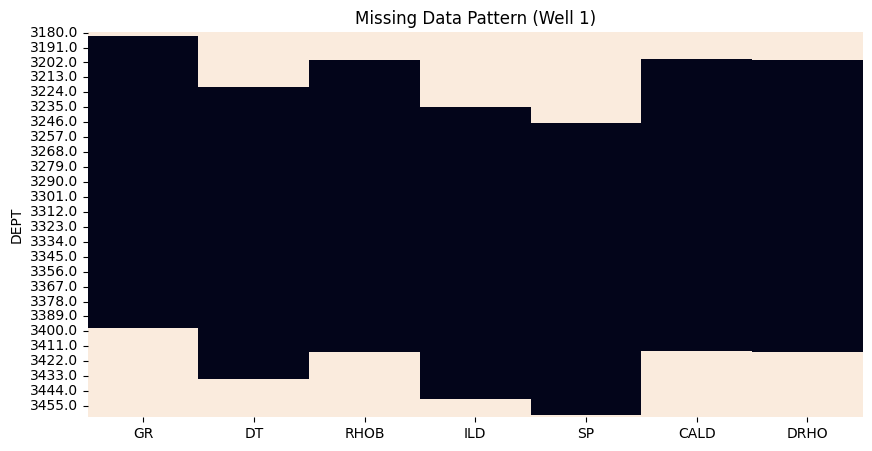

In [ ]:
plt.figure(figsize=(10,5))
sns.heatmap(df1_selected.isnull(), cbar=False)
plt.title("Missing Data Pattern (Well 1)")
plt.show()



In [ ]:
# Handle missing values (interpolation)
# Interpolate along depth
# Fill any remaining large gaps with mean values
# Well 1

df1_final = df1_selected.interpolate(method='linear', limit_direction='both')
df2_final = df2_selected.interpolate(method='linear', limit_direction='both')
df3_final = df3_selected.interpolate(method='linear', limit_direction='both')
df4_final = df4_selected.interpolate(method='linear', limit_direction='both')

from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy='mean')
df1_final = pd.DataFrame(imputer.fit_transform(df1_selected), columns=df1_selected.columns, index=df1_selected.index)
df2_final = pd.DataFrame(imputer.fit_transform(df2_selected), columns=df2_selected.columns, index=df2_selected.index)
df3_final = pd.DataFrame(imputer.fit_transform(df3_selected), columns=df3_selected.columns, index=df3_selected.index)
df4_final = pd.DataFrame(imputer.fit_transform(df4_selected), columns=df4_selected.columns, index=df4_selected.index)


# If you've already handled missing values
print("=== WELL 1 (after interpolation/imputation) ===")
print(df1_final.head(), "\n")

print("=== WELL 2 (after interpolation/imputation) ===")
print(df2_final.head(), "\n")

print("=== WELL 3 (after interpolation/imputation) ===")
print(df3_final.head(), "\n")

print("=== WELL 4 (after interpolation/imputation) ===")
print(df4_final.head(), "\n")



=== WELL 1 (after interpolation/imputation) ===
            GR        DT      RHOB        ILD        SP   CALD      DRHO
DEPT                                                                    
3180.0  49.103  66.30761  2.666953  35.080698 -8.579791  7.707  0.028233
3180.5  49.103  66.30761  2.666953  35.080698 -8.579791  7.707  0.028233
3181.0  49.103  66.30761  2.666953  35.080698 -8.579791  7.707  0.028233
3181.5  49.103  66.30761  2.666953  35.080698 -8.579791  7.707  0.028233
3182.0  49.103  66.30761  2.666953  35.080698 -8.579791  7.707  0.028233 

=== WELL 2 (after interpolation/imputation) ===
              GR         DT      RHOB        ILD         SP      CALD  \
DEPT                                                                    
152.5  76.404279  91.409715  2.479543  26.984755 -21.746874  8.005198   
153.0  76.404279  91.409715  2.479543  26.984755 -21.746874  8.005198   
153.5  76.404279  91.409715  2.479543  26.984755 -21.746874  8.005198   
154.0  76.404279  91.40971

In [ ]:
# Remove outliers using Isolation Forest
def remove_outliers_iqr(df, factor=2.0):
    df_clean = df.copy()
    for col in df_clean.columns:
        if col != 'DEPT':  # skip depth column
            Q1 = df_clean[col].quantile(0.25)
            Q3 = df_clean[col].quantile(0.75)
            IQR = Q3 - Q1
            lower = Q1 - factor * IQR
            upper = Q3 + factor * IQR
            df_clean = df_clean[(df_clean[col] >= lower) & (df_clean[col] <= upper)]
    return df_clean

df1_no_outliers = remove_outliers_iqr(df1_final, factor=2.0)
df2_no_outliers = remove_outliers_iqr(df2_final, factor=2.0)
df3_no_outliers = remove_outliers_iqr(df3_final, factor=2.0)
df4_no_outliers = remove_outliers_iqr(df4_final, factor=2.0)



# checking the removal effect
for i, (before, after) in enumerate(
    zip([df1_final, df2_final, df3_final, df4_final],
        [df1_no_outliers, df2_no_outliers, df3_no_outliers, df4_no_outliers]),
    start=1):
    print(f"Well {i}: Before = {len(before)}, After = {len(after)}, Removed = {len(before) - len(after)}")

# View first few rows after outlier removal
print("=== WELL 1 (after outlier removal) ===")
print(df1_no_outliers.head(), "\n")
print("=== WELL 2 (after outlier removal) ===")
print(df2_no_outliers.head(), "\n")
print("=== WELL 3 (after outlier removal) ===")
print(df3_no_outliers.head(), "\n")
print("=== WELL 4 (after outlier removal) ===")
print(df4_no_outliers.head(), "\n")





Well 1: Before = 567, After = 398, Removed = 169
Well 2: Before = 6622, After = 5351, Removed = 1271
Well 3: Before = 567, After = 398, Removed = 169
Well 4: Before = 565, After = 462, Removed = 103
=== WELL 1 (after outlier removal) ===
            GR        DT      RHOB        ILD        SP   CALD      DRHO
DEPT                                                                    
3180.0  49.103  66.30761  2.666953  35.080698 -8.579791  7.707  0.028233
3180.5  49.103  66.30761  2.666953  35.080698 -8.579791  7.707  0.028233
3181.0  49.103  66.30761  2.666953  35.080698 -8.579791  7.707  0.028233
3181.5  49.103  66.30761  2.666953  35.080698 -8.579791  7.707  0.028233
3182.0  49.103  66.30761  2.666953  35.080698 -8.579791  7.707  0.028233 

=== WELL 2 (after outlier removal) ===
              GR         DT      RHOB        ILD         SP      CALD  \
DEPT                                                                    
152.5  76.404279  91.409715  2.479543  26.984755 -21.746874  8.0

In [ ]:
# Scale the data

def scale_logs(df):
    df_scaled = df.copy()
    if 'DEPT' in df_scaled.columns:
        depth = df_scaled['DEPT']
        df_scaled = df_scaled.drop(columns=['DEPT'])
        df_scaled = pd.DataFrame(scaler.fit_transform(df_scaled), columns=df_scaled.columns)
        df_scaled['DEPT'] = depth.values
    else:
        df_scaled = pd.DataFrame(scaler.fit_transform(df_scaled), columns=df_scaled.columns)
    return df_scaled

df1_scaled = scale_logs(df1_no_outliers)
df2_scaled = scale_logs(df2_no_outliers)
df3_scaled = scale_logs(df3_no_outliers)
df4_scaled = scale_logs(df4_no_outliers)

print(df1_scaled.head())
print(df2_scaled.head())
print(df3_scaled.head())
print(df4_scaled.head())


         GR        DT      RHOB       ILD        SP  CALD      DRHO
0  0.427805  0.459966  0.434767  0.446466  0.385479   0.7  0.546179
1  0.427805  0.459966  0.434767  0.446466  0.385479   0.7  0.546179
2  0.427805  0.459966  0.434767  0.446466  0.385479   0.7  0.546179
3  0.427805  0.459966  0.434767  0.446466  0.385479   0.7  0.546179
4  0.427805  0.459966  0.434767  0.446466  0.385479   0.7  0.546179
         GR        DT      RHOB       ILD        SP      CALD      DRHO
0  0.268648  0.500081  0.481378  0.508402  0.557945  0.379332  0.508137
1  0.268648  0.500081  0.481378  0.508402  0.557945  0.379332  0.508137
2  0.268648  0.500081  0.481378  0.508402  0.557945  0.379332  0.508137
3  0.268648  0.500081  0.481378  0.508402  0.557945  0.379332  0.508137
4  0.268648  0.500081  0.481378  0.508402  0.557945  0.379332  0.508137
         GR        DT      RHOB       ILD        SP  CALD      DRHO
0  0.427805  0.459966  0.434767  0.446466  0.385479   0.7  0.546179
1  0.427805  0.459966  0

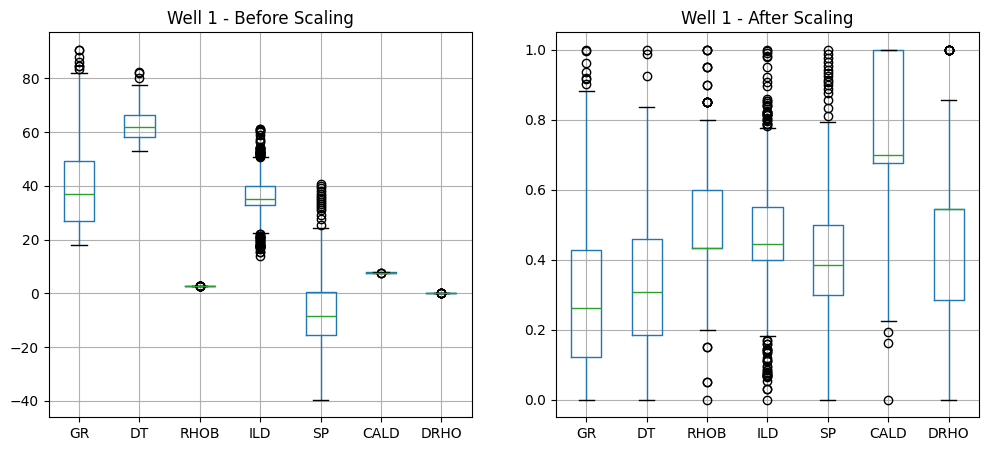

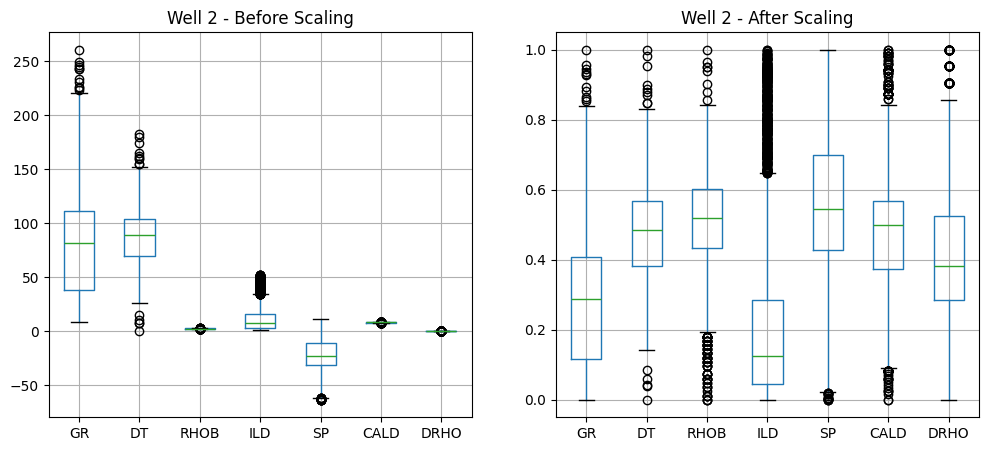

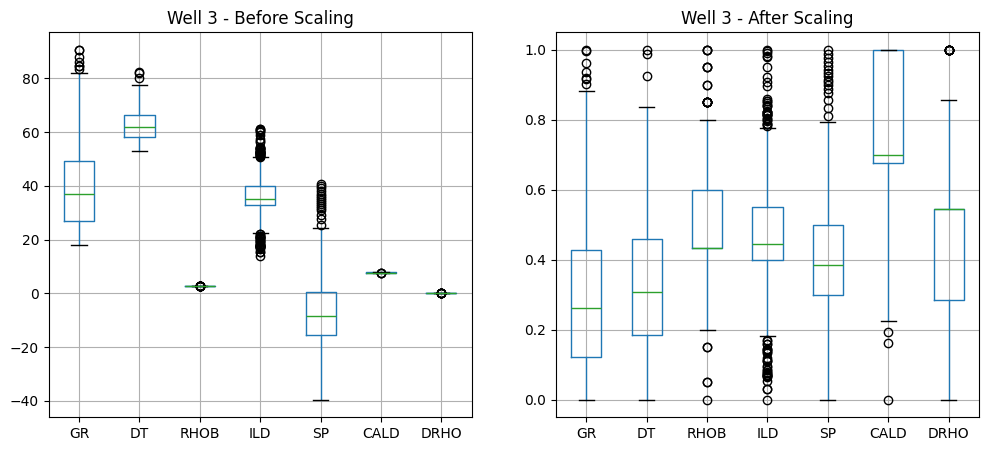

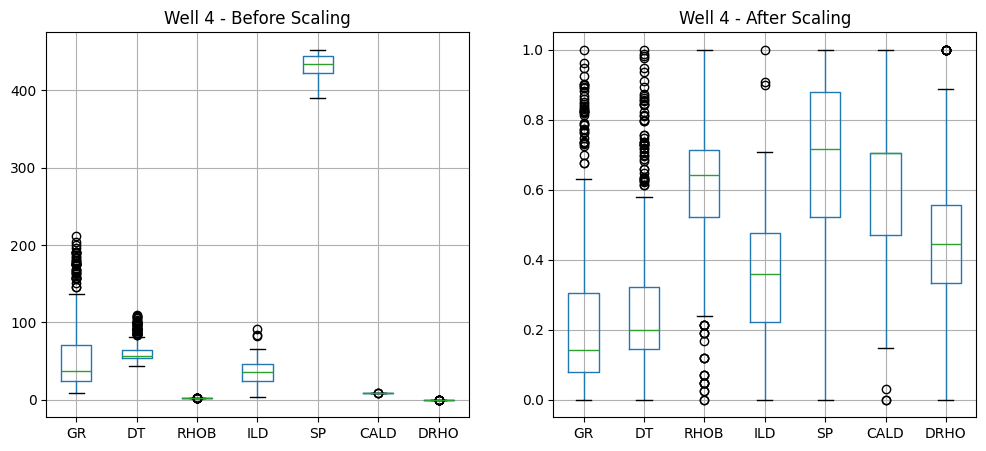

In [ ]:
# Verifying the Scaling Effect

def compare_scaling(df_original, df_scaled, title):
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    df_original.boxplot(ax=axes[0])
    axes[0].set_title(f"{title} - Before Scaling")
    df_scaled.boxplot(ax=axes[1])
    axes[1].set_title(f"{title} - After Scaling")
    plt.show()
compare_scaling(df1_no_outliers, df1_scaled, "Well 1")
compare_scaling(df2_no_outliers, df2_scaled, "Well 2")
compare_scaling(df3_no_outliers, df3_scaled, "Well 3")
compare_scaling(df4_no_outliers, df4_scaled, "Well 4")



In [ ]:
# Anomaly Detection using Isolation Forest
# Well 1
iso = IsolationForest(contamination=0.05, random_state=42)
iso.fit(df1_scaled)

# Predict anomalies
df1_scaled['Anomaly'] = iso.predict(df1_scaled)
df1_scaled['Anomaly'] = df1_scaled['Anomaly'].map({1: 'Normal', -1: 'Anomaly'})

# Well 2
iso.fit(df2_scaled)
# Predict anomalies
df2_scaled['Anomaly'] = iso.predict(df2_scaled)
df2_scaled['Anomaly'] = df2_scaled['Anomaly'].map({1: 'Normal', -1: 'Anomaly'})
# Well 3
iso.fit(df3_scaled)
# Predict anomalies
df3_scaled['Anomaly'] = iso.predict(df3_scaled)
df3_scaled['Anomaly'] = df3_scaled['Anomaly'].map({1: 'Normal', -1: 'Anomaly'})
# Well 4    
iso.fit(df4_scaled)
# Predict anomalies
df4_scaled['Anomaly'] = iso.predict(df4_scaled)
df4_scaled['Anomaly'] = df4_scaled['Anomaly'].map({1: 'Normal', -1: 'Anomaly'})
# View anomalies
print("=== WELL 1 Anomalies ===")
print(df1_scaled[df1_scaled['Anomaly'] == 'Anomaly'], "\n")
print("=== WELL 2 Anomalies ===")
print(df2_scaled[df2_scaled['Anomaly'] == 'Anomaly'], "\n")
print("=== WELL 3 Anomalies ===")
print(df3_scaled[df3_scaled['Anomaly'] == 'Anomaly'], "\n")
print("=== WELL 4 Anomalies ===")
print(df4_scaled[df4_scaled['Anomaly'] == 'Anomaly'], "\n")




=== WELL 1 Anomalies ===
           GR        DT  RHOB       ILD        SP      CALD      DRHO  Anomaly
107  0.115660  0.064264  0.40  0.923289  0.385479  1.000000  0.714286  Anomaly
178  0.820513  0.583475  0.60  0.000000  0.387466  0.967742  0.142857  Anomaly
179  0.868486  0.988779  0.30  0.071823  0.419672  1.000000  0.428571  Anomaly
201  0.789082  0.722543  0.60  0.119210  0.424521  0.967742  0.714286  Anomaly
204  0.613868  0.671880  0.95  0.052274  0.081696  0.903226  0.285714  Anomaly
205  0.403226  0.460728  1.00  0.139397  0.088038  0.903226  0.285714  Anomaly
206  0.391095  0.453587  1.00  0.259244  0.100224  0.903226  0.285714  Anomaly
207  0.334436  0.390343  0.95  0.514025  0.127580  0.903226  0.142857  Anomaly
209  0.396057  0.236654  0.85  0.635784  0.148222  0.903226  0.000000  Anomaly
210  0.392473  0.228154  0.85  0.659159  0.155931  0.903226  0.000000  Anomaly
270  0.170113  0.089765  0.35  0.318317  0.031460  0.516129  1.000000  Anomaly
271  0.053350  0.299218  0.

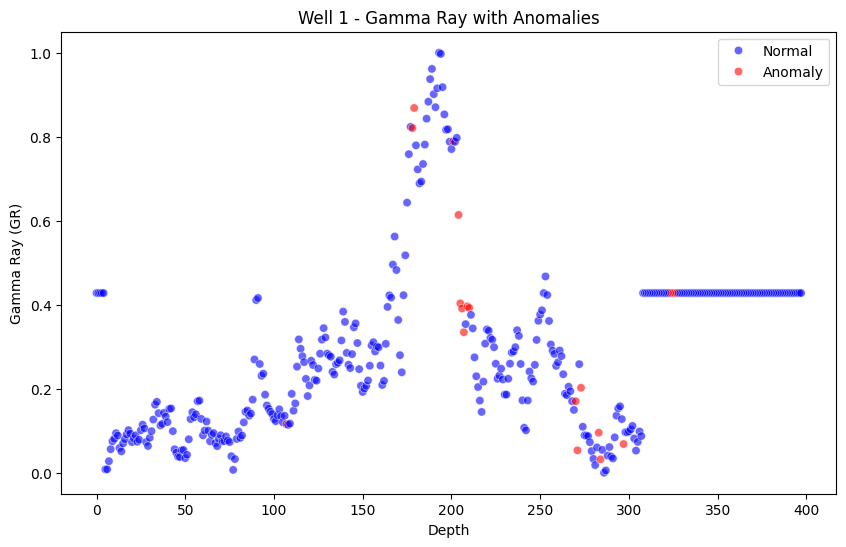

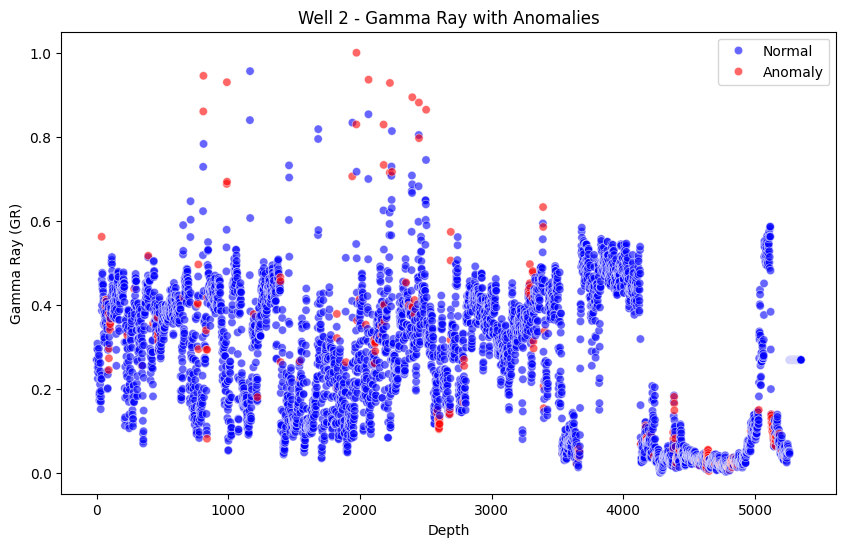

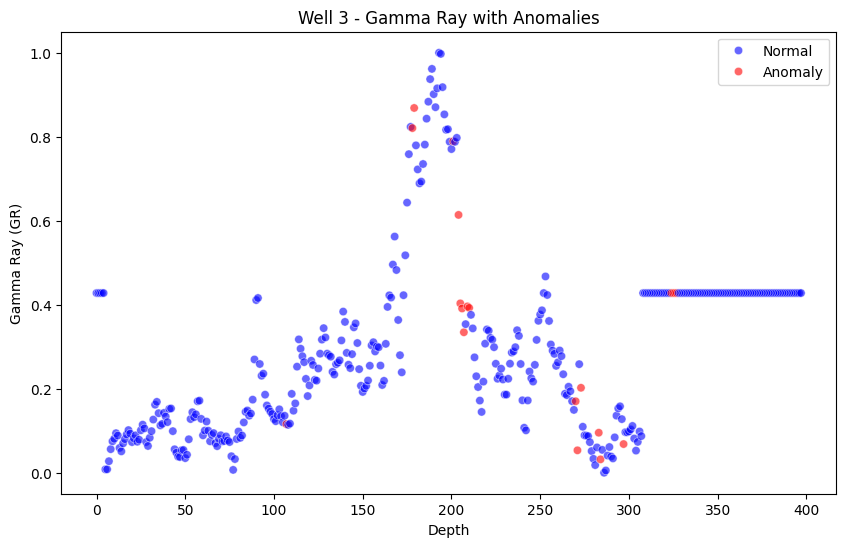

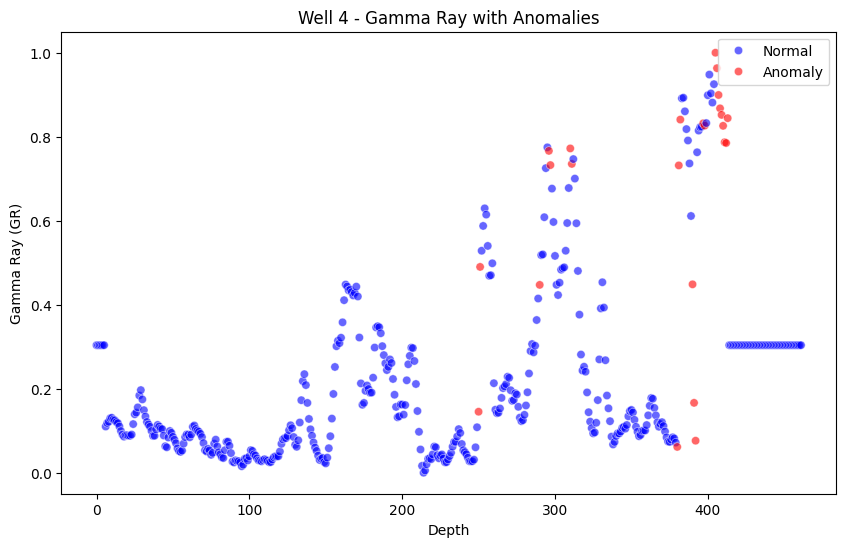

KeyError: 'DEPT'

<Figure size 600x800 with 0 Axes>

In [ ]:
# Visualize anomalies


# Gamma Ray (GR) vs Depth with anomalies highlighted
def plot_anomalies(df, title):
    plt.figure(figsize=(10, 6))
    sns.scatterplot(data=df, x=df.index, y='GR', hue='Anomaly', palette={'Normal': 'blue', 'Anomaly': 'red'}, alpha=0.6)
    plt.title(f"{title} - Gamma Ray with Anomalies")
    plt.xlabel("Depth")
    plt.ylabel("Gamma Ray (GR)")
    plt.legend()
    plt.show()
plot_anomalies(df1_scaled, "Well 1")
plot_anomalies(df2_scaled, "Well 2")
plot_anomalies(df3_scaled, "Well 3")
plot_anomalies(df4_scaled, "Well 4")

# Plot multiple features against depth with anomalies highlighted
for feature in ['GR', 'RHOB', 'DT', 'ILD']:
    plt.figure(figsize=(6, 8))
    plt.scatter(df1_no_outliers[feature], df1_no_outliers['DEPT'], 
                c=(df1_scaled['Anomaly'] == 'Anomaly'), cmap='coolwarm', s=10)
    plt.gca().invert_yaxis()
    plt.title(f"{feature} vs Depth (Well 1)")
    plt.xlabel(feature)
    plt.ylabel("Depth (m)")
    plt.show()

In [ ]:
print("df1 columns:", df1.columns)
print("df1_no_outliers columns:", df1_no_outliers.columns)
print("df1.index.name:", df1.index.name)

df1_no_outliers = df1_no_outliers.reset_index()  # brings DEPT back as a column
print(df1_no_outliers.columns)



df1 columns: Index(['DEPT', 'DT', 'CILD', 'CALN', 'CALD', 'GR', 'ILD', 'ILM', 'MINV',
       'LWTLB', 'CALM', 'MNOR', 'NPLS', 'DPLS', 'PORS', 'SFL', 'SP', 'TT1',
       'TT2', 'TT3', 'TT4', 'DRHO', 'RHOB', 'PE'],
      dtype='object')
df1_no_outliers columns: Index(['DEPT', 'GR', 'DT', 'RHOB', 'ILD', 'SP', 'CALD', 'DRHO'], dtype='object')
df1.index.name: None
Index(['index', 'DEPT', 'GR', 'DT', 'RHOB', 'ILD', 'SP', 'CALD', 'DRHO'], dtype='object')


In [ ]:
wells = {
    "Well 1": (df1_no_outliers, df1_scaled),
    "Well 2": (df2_no_outliers, df2_scaled),
    "Well 3": (df3_no_outliers, df3_scaled),
    "Well 4": (df4_no_outliers, df4_scaled),
}

# Features to plot
features = ['GR', 'RHOB', 'DT', 'ILD', 'GR', 'SP', 'CALD', 'DRHO']
for well_name, (df_no_outliers, df_anomaly) in wells.items():
    for feature in features:
        if feature in df_no_outliers.columns:
            plt.figure(figsize=(6, 8))
            plt.scatter(df_no_outliers[feature], df_no_outliers['DEPT'], 
                        c=(df_anomaly['Anomaly'] == 'Anomaly'), cmap='coolwarm', s=10)
            plt.gca().invert_yaxis()
            plt.title(f"{feature} vs Depth ({well_name})")
            plt.xlabel(feature)
            plt.ylabel("Depth (m)")
            plt.scatter([], [], c='blue', label='Normal', s=20)
            plt.scatter([], [], c='red', label='Anomaly', s=20)
            plt.legend(loc='upper right', title='Data Type')
            plt.show()
        else:
            print(f"Feature {feature} not found in {well_name}, skipping plot.")

# Display anomalies for each well
print("=== WELL 1 Anomalies ===")
print(df1_scaled[df1_scaled['Anomaly'] == 'Anomaly'], "\n")
print("=== WELL 2 Anomalies ===")
print(df2_scaled[df2_scaled['Anomaly'] == 'Anomaly'], "\n")
print("=== WELL 3 Anomalies ===")
print(df3_scaled[df3_scaled['Anomaly'] == 'Anomaly'], "\n")
print("=== WELL 4 Anomalies ===")
print(df4_scaled[df4_scaled['Anomaly'] == 'Anomaly'], "\n")



NameError: name 'df1_scaled' is not defined

In [ ]:
# List of wells
wells = {
    "Well 1": df1_scaled,
    "Well 2": df2_scaled,
    "Well 3": df3_scaled,
    "Well 4": df4_scaled,
}

features = ['GR', 'RHOB', 'DT', 'ILD']

# Loop through wells to compute anomaly summary
for well_name, df_scaled in wells.items():
    print(f"\n===== {well_name} Anomaly Metrics =====")
    
    # Count anomalies
    total_points = len(df_scaled)
    anomalies = df_scaled[df_scaled['ANOMALY'] == 'Anomaly'].shape[0]
    anomaly_ratio = (anomalies / total_points) * 100

    print(f"Total Data Points: {total_points}")
    print(f"Detected Anomalies: {anomalies} ({anomaly_ratio:.2f}%)")

    # Compare statistics between normal and anomalies
    summary = df_scaled.groupby('ANOMALY')[features].describe().T
    print("\nFeature-wise Statistics (Normal vs Anomalous):")
    print(summary)
    print("\n--------------------------------------------")



===== Well 1 Anomaly Metrics =====
Total Data Points: 398
Detected Anomalies: 20 (5.03%)

Feature-wise Statistics (Normal vs Anomalous):
ANOMALY       Anomaly      Normal
GR   count  20.000000  378.000000
     mean    0.334227   -0.017684
     std     1.267947    0.984093
     min    -1.338760   -1.427183
     25%    -0.691502   -0.840045
     50%     0.488635   -0.166160
     75%     0.651613    0.651613
     max     2.792974    3.432026
RHOB count  20.000000  378.000000
     mean    0.435755   -0.023056
     std     1.823891    0.936720
     min    -2.700988   -3.002598
     25%    -0.966731   -0.379994
     50%     0.164306   -0.379994
     75%     2.124771    0.616721
     max     3.029601    2.727991
DT   count  20.000000  378.000000
     mean    0.590706   -0.031254
     std     1.590105    0.953302
     min    -1.380694   -1.801513
     25%    -0.625459   -0.858700
     50%     0.236324   -0.215833
     75%     1.803649    0.620900
     max     3.464987    2.596489
ILD  count  

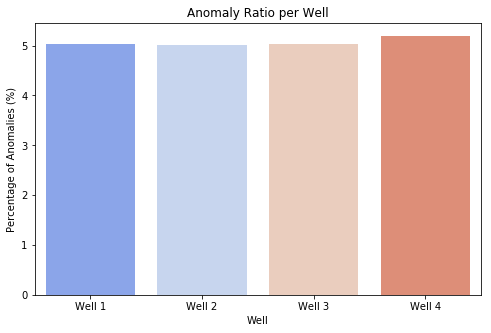

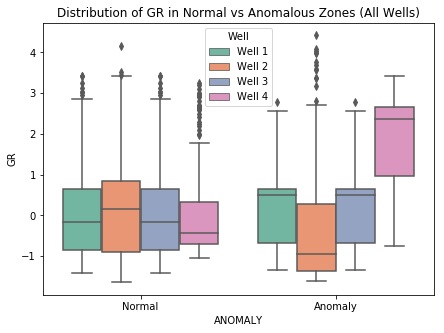

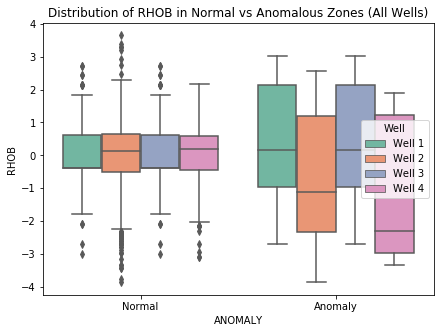

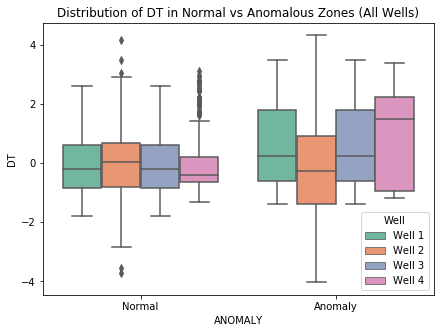

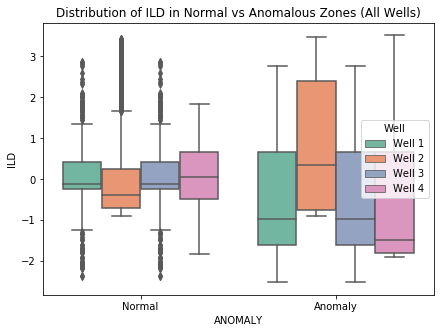

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Step 1: Create a summary table
summary_data = []
for well_name, df_scaled in wells.items():
    total_points = len(df_scaled)
    anomalies = df_scaled[df_scaled['ANOMALY'] == 'Anomaly'].shape[0]
    anomaly_ratio = (anomalies / total_points) * 100
    summary_data.append({"Well": well_name, "Total": total_points, "Anomalies": anomalies, "Anomaly %": anomaly_ratio})

summary_df = pd.DataFrame(summary_data)

# Step 2: Bar chart of anomaly ratios
plt.figure(figsize=(8, 5))
sns.barplot(data=summary_df, x='Well', y='Anomaly %', palette='coolwarm')
plt.title("Anomaly Ratio per Well")
plt.ylabel("Percentage of Anomalies (%)")
plt.xlabel("Well")
plt.show()

# Step 3: Boxplots comparing Normal vs Anomaly for one key feature (e.g. GR)
for feature in features:
    plt.figure(figsize=(7, 5))
    sns.boxplot(data=pd.concat(wells.values(), keys=wells.keys()).reset_index(level=0).rename(columns={'level_0': 'Well'}),
                x='ANOMALY', y=feature, hue='Well', palette='Set2')
    plt.title(f"Distribution of {feature} in Normal vs Anomalous Zones (All Wells)")
    plt.show()


In [ ]:
summary_df.to_csv("Anomaly_Summary_All_Wells.csv", index=False)
print("✅ Anomaly summary saved as 'Anomaly_Summary_All_Wells.csv'")


✅ Anomaly summary saved as 'Anomaly_Summary_All_Wells.csv'


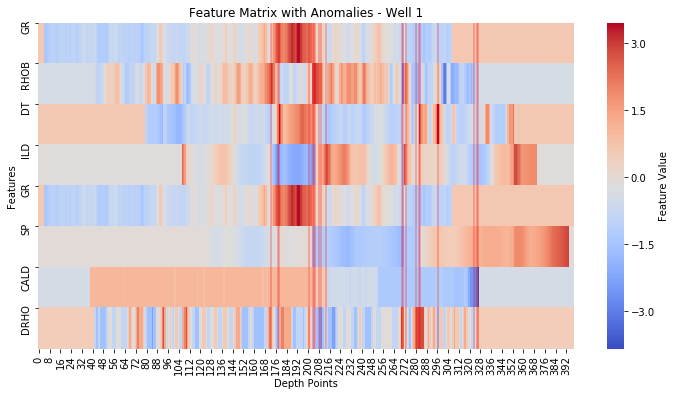

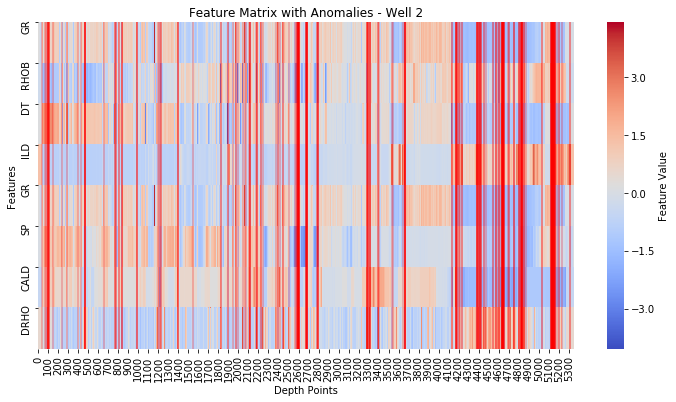

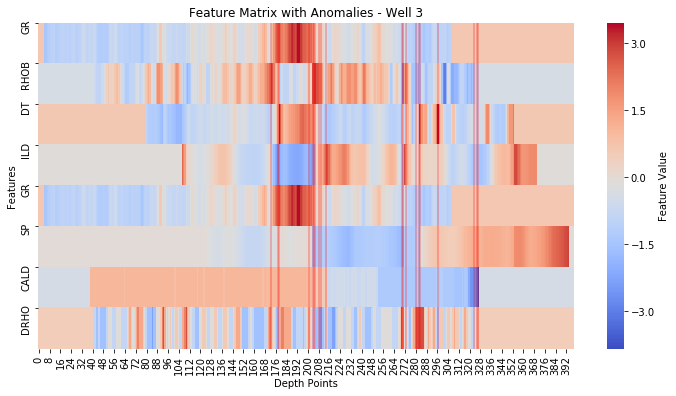

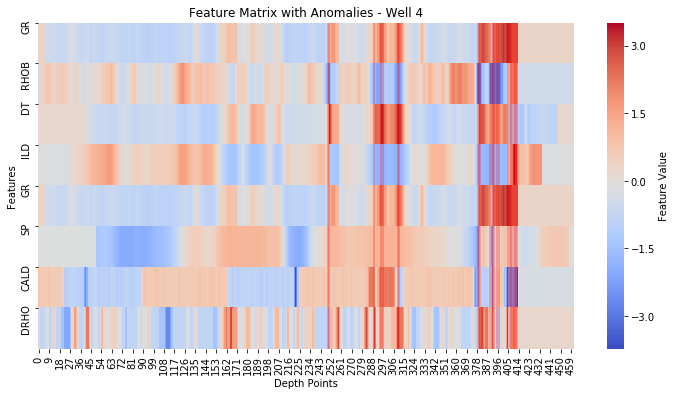

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# List of wells
wells = {
    "Well 1": df1_scaled,
    "Well 2": df2_scaled,
    "Well 3": df3_scaled,
    "Well 4": df4_scaled,
}

features = ['GR', 'RHOB', 'DT', 'ILD', 'GR', 'SP', 'CALD', 'DRHO']

# Loop through each well
for well_name, df in wells.items():
    # Create a numeric matrix for features
    feature_matrix = df[features]
    
    # Plot heatmap
    plt.figure(figsize=(12,6))
    sns.heatmap(feature_matrix.T, cmap='coolwarm', cbar_kws={'label': 'Feature Value'})
    
    # Highlight anomalies with a vertical line or color map
    anomaly_points = df[df['ANOMALY']=='Anomaly'].index
    for point in anomaly_points:
        plt.axvline(x=point, color='red', alpha=0.3)  # vertical red line for anomaly
    
    plt.yticks(range(len(features)), features)
    plt.title(f"Feature Matrix with Anomalies - {well_name}")
    plt.xlabel("Depth Points")
    plt.ylabel("Features")
    plt.show()


In [ ]:

# Define the wells and features
las_files = {
    "Well 1": r"C:\Users\LENOVO\Downloads\SASTRA PROJECT\WELL DATA\DATA\File 1.las",
    "Well 2": r"C:\Users\LENOVO\Downloads\SASTRA PROJECT\WELL DATA\DATA\File 2.las",
    "Well 3": r"C:\Users\LENOVO\Downloads\SASTRA PROJECT\WELL DATA\DATA\File 3.las",
    "Well 4": r"C:\Users\LENOVO\Downloads\SASTRA PROJECT\WELL DATA\DATA\File 4.las",
}

features = ['GR', 'RHOB', 'DT', 'ILD', 'SP', 'CALD', 'DRHO']

# === Step 2: Create folders for plots and output ===
os.makedirs("plots", exist_ok=True)
pdf_output = "Anomaly_Detection_Report_Corrected.pdf"

# === Step 3: Initialize PDF ===
pdf = FPDF()
pdf.set_auto_page_break(auto=True, margin=15)

# === Step 4: Generate report for each well ===
for well_name, df in wells.items():
    pdf.add_page()
    pdf.set_font("Arial", 'B', 16)
    pdf.cell(0, 10, f"Anomaly Detection Report - {well_name}", ln=True, align="C")
    
    # --- General Metrics ---
    total_points = len(df)
    anomalies = df[df['ANOMALY'] == 'Anomaly'].shape[0]
    anomaly_ratio = (anomalies / total_points) * 100

    pdf.set_font("Arial", '', 12)
    pdf.ln(5)
    pdf.cell(0, 8, f"Total Data Points: {total_points}", ln=True)
    pdf.cell(0, 8, f"Detected Anomalies: {anomalies} ({anomaly_ratio:.2f}%)", ln=True)

    # --- Feature-wise Summary ---
    summary = df.groupby('ANOMALY')[features].describe().T
    pdf.ln(5)
    pdf.cell(0, 8, "Feature-wise Statistics (Normal vs Anomalous):", ln=True)
    
    # Convert summary to string for PDF
    summary_str = summary.to_string()
    pdf.set_font("Courier", '', 8)
    pdf.multi_cell(0, 5, summary_str)
    pdf.set_font("Arial", '', 12)
    
    # --- Plots ---
    for feature in features:
        plt.figure(figsize=(5, 8))
        plt.scatter(df[feature], df['DEPT'], 
                    c=(df['ANOMALY'] == 'Anomaly'), cmap='coolwarm', s=10)
        plt.gca().invert_yaxis()
        plt.title(f"{feature} vs Depth ({well_name})")
        plt.xlabel(feature)
        plt.ylabel("Depth (m)")
        plt.scatter([], [], c='blue', label='Normal', s=20)
        plt.scatter([], [], c='red', label='Anomaly', s=20)
        plt.legend(loc='upper right', title='Data Type')
        
        plot_path = f"plots/{well_name}_{feature}.png"
        plt.savefig(plot_path, bbox_inches='tight')
        plt.close()
        
        pdf.image(plot_path, w=180)
        pdf.ln(5)

# === Step 5: Save PDF ===
pdf.output(pdf_output)
print(f"PDF report generated: {pdf_output}")


PDF report generated: Anomaly_Detection_Report_Corrected.pdf


In [ ]:
import lasio

# Read one LAS file
las = lasio.read(r"C:\Users\LENOVO\Downloads\SASTRA PROJECT\WELL DATA\DATA\File 1.las")
df = las.df()

# Print all column names to inspect
print("Columns in LAS file:", df.columns)

# Define depth candidates (case-insensitive, allow spaces)
depth_candidates = ['DEPT', 'DEPTH', 'MD', 'TVD']

# Try to detect depth column
depth_col = None
for col in df.columns:
    col_clean = col.upper().replace(" ", "").replace("(", "").replace(")", "")
    if any(dc.upper() == col_clean for dc in depth_candidates):
        depth_col = col
        break

if depth_col is None:
    # If still not found, print columns for manual inspection
    print("Could not find depth column. LAS columns are:", df.columns)
else:
    print("Detected depth column:", depth_col)


ValueError: No depth column found in Well 1

In [ ]:
import lasio
import pandas as pd

# Read LAS file
las = lasio.read(r"C:\Users\LENOVO\Downloads\SASTRA PROJECT\WELL DATA\DATA\File 1.las")
df = las.df()

# Inspect available columns
print("Columns in LAS:", df.columns)

# Try to detect depth column automatically
depth_candidates = ['DEPT', 'DEPTH', 'MD', 'TVD']
depth_col = next((col for col in df.columns if col.upper().strip() in depth_candidates), None)

if depth_col is None:
    raise ValueError("No depth column found in LAS file!")

print("Detected depth column:", depth_col)

# Include features + depth safely
features = ['GR', 'DT', 'RHOB', 'ILD']  # example features
available_features = [f for f in features if f in df.columns]  # only existing ones
df = df[available_features + [depth_col]].reset_index(drop=True)

print(df.head())


Columns in LAS: Index(['DT', 'CILD', 'CALN', 'CALD', 'GR', 'ILD', 'ILM', 'MINV', 'LWTLB',
       'CALM', 'MNOR', 'NPLS', 'DPLS', 'PORS', 'SFL', 'SP', 'TT1', 'TT2',
       'TT3', 'TT4', 'DRHO', 'RHOB', 'PE'],
      dtype='object')


ValueError: No depth column found in LAS file!

In [ ]:
import lasio
import pandas as pd

def load_well(file_path, features=None, depth_candidates=None):
    las = lasio.read(file_path)
    df = las.df().reset_index()  # include depth as column
    df.columns = df.columns.str.upper()  # uppercase columns
    
    if features is None:
        features = ['DEPT', 'GR', 'DT', 'RHOB', 'ILD', 'SP', 'CALD', 'DRHO']
    
    if depth_candidates is None:
        depth_candidates = ['DEPT', 'DEPTH', 'MD', 'TVD']
    
    # Detect depth column
    depth_col = next((col for col in df.columns if col in depth_candidates), None)
    if depth_col is None:
        raise ValueError(f"No depth column found in {file_path}")
    
    # Keep only available features + detected depth
    available = [f for f in features if f in df.columns]
    if depth_col not in available:
        available = [depth_col] + available  # ensure depth is included
    
    missing = [f for f in features if f not in df.columns]
    
    df_selected = df[available].copy()
    df_selected.rename(columns={depth_col: 'DEPT'}, inplace=True)  # rename for consistency
    
    if missing:
        print(f"Warning: Missing features in {file_path}: {missing}")
    print(f"Using features from {file_path}: {list(df_selected.columns)}")
    
    return df_selected

# Example usage:
df1_selected = load_well(Well_1)
df2_selected = load_well(Well_2)
df3_selected = load_well(Well_3)
df4_selected = load_well(Well_4)


Using features from C:\Users\LENOVO\Downloads\SASTRA PROJECT\WELL DATA\DATA\File 1.las: ['DEPT', 'GR', 'DT', 'RHOB', 'ILD', 'SP', 'CALD', 'DRHO']
Using features from C:\Users\LENOVO\Downloads\SASTRA PROJECT\WELL DATA\DATA\File 2.las: ['DEPT', 'GR', 'DT', 'RHOB', 'ILD', 'SP', 'CALD', 'DRHO']
Using features from C:\Users\LENOVO\Downloads\SASTRA PROJECT\WELL DATA\DATA\File 3.las: ['DEPT', 'GR', 'DT', 'RHOB', 'ILD', 'SP', 'CALD', 'DRHO']
Using features from C:\Users\LENOVO\Downloads\SASTRA PROJECT\WELL DATA\DATA\File 4.las: ['DEPT', 'GR', 'DT', 'RHOB', 'ILD', 'SP', 'CALD', 'DRHO']


Well 1 saved to Well_1_cleaned.csv
Well 2 saved to Well_2_cleaned.csv
Well 3 saved to Well_3_cleaned.csv
Well 4 saved to Well_4_cleaned.csv
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step
207/207 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 


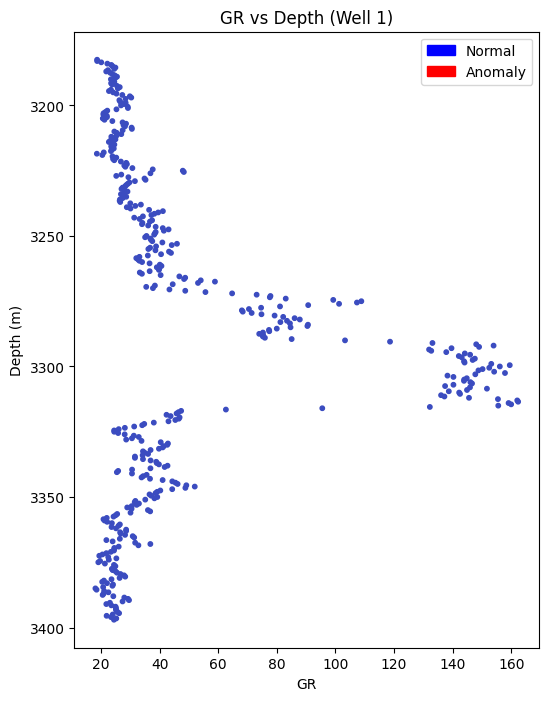

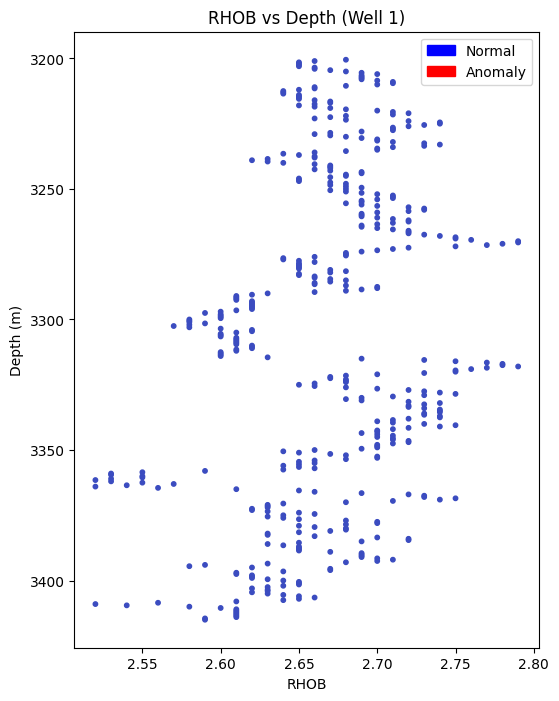

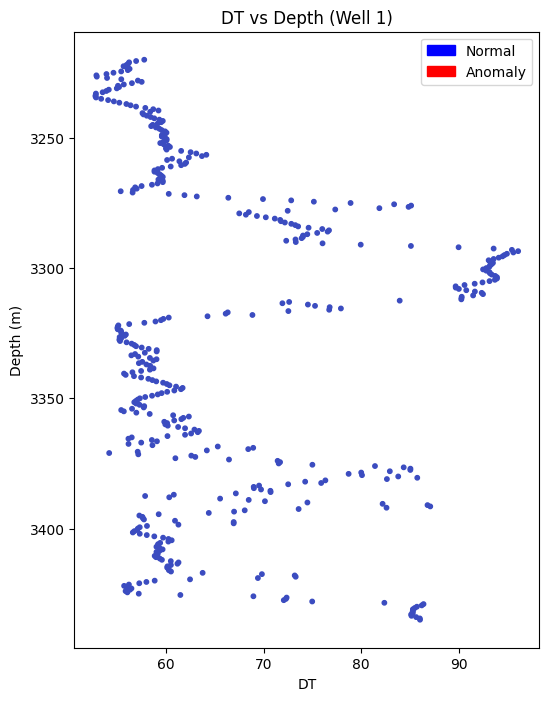

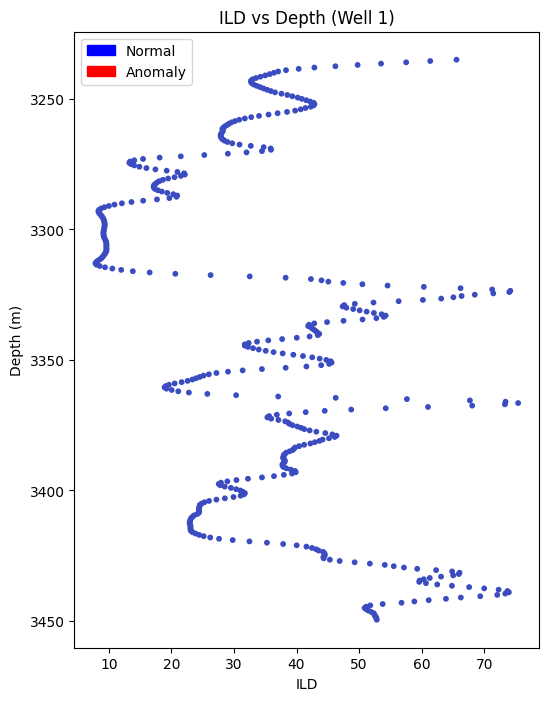

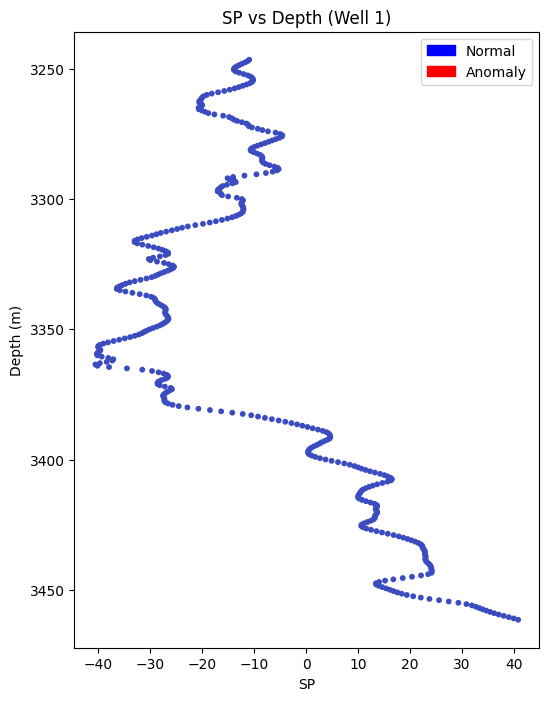

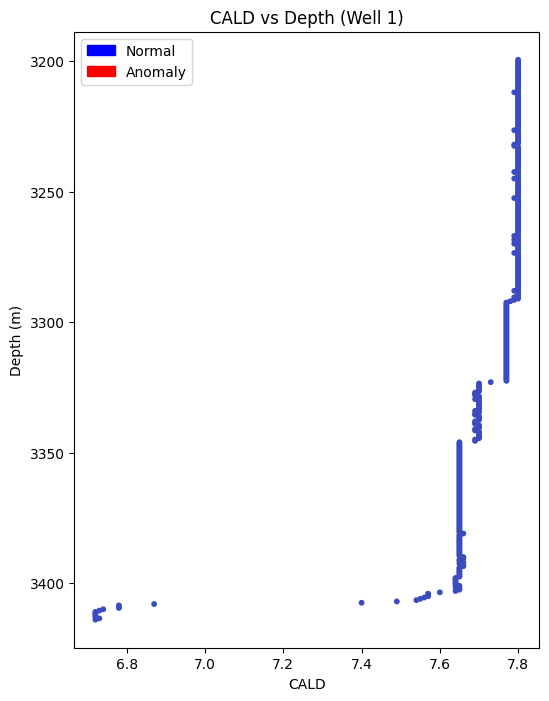

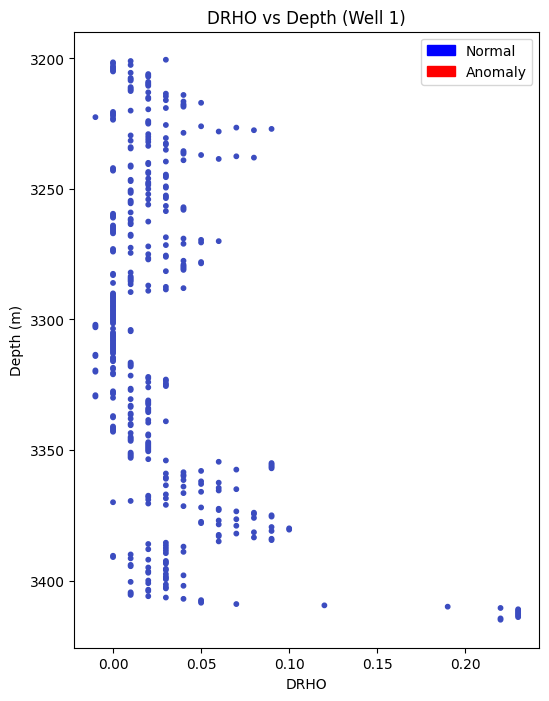

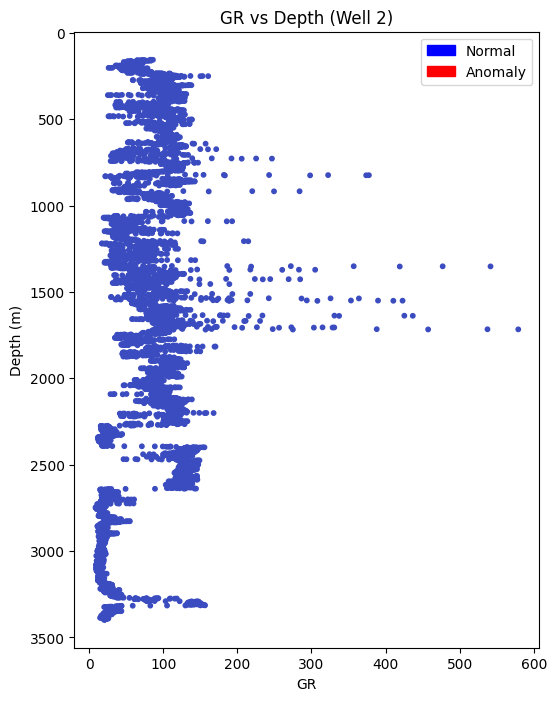

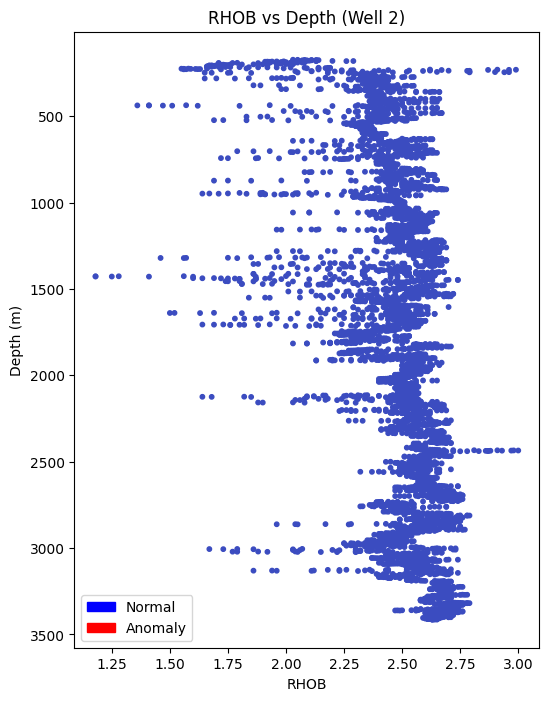

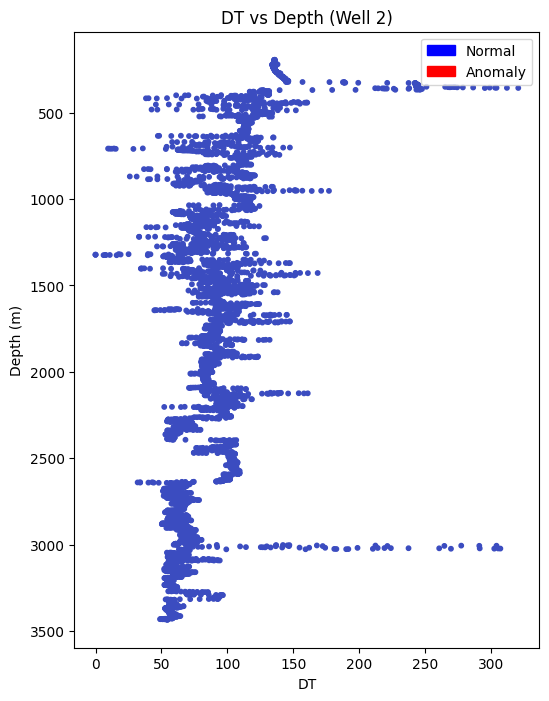

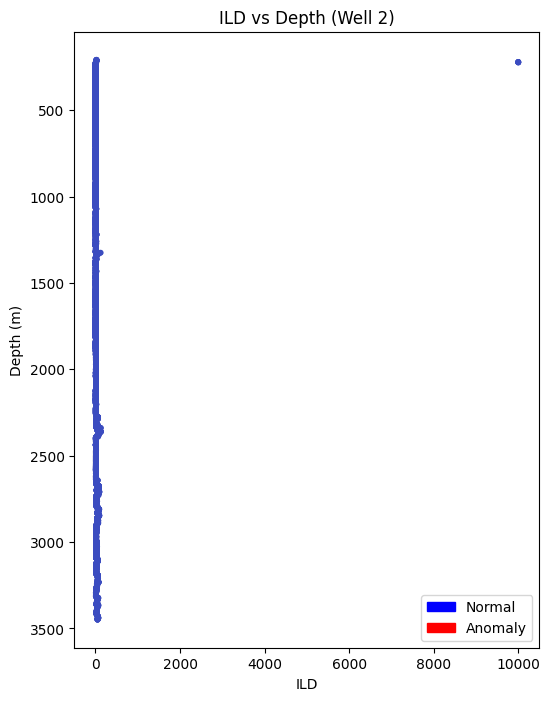

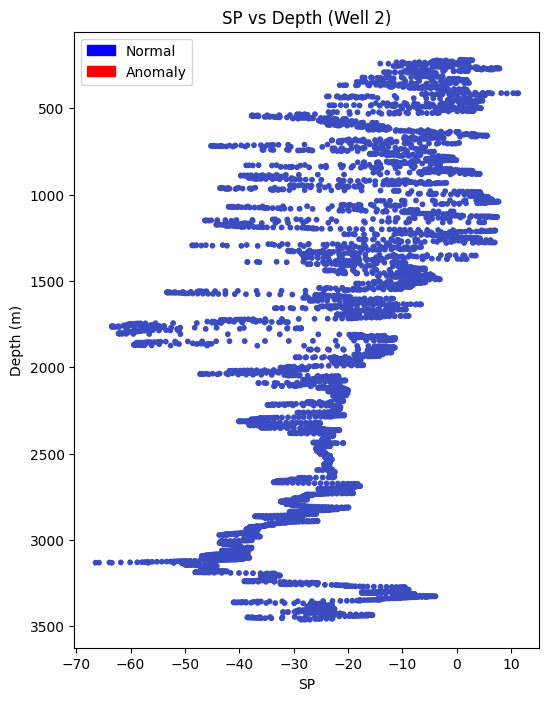

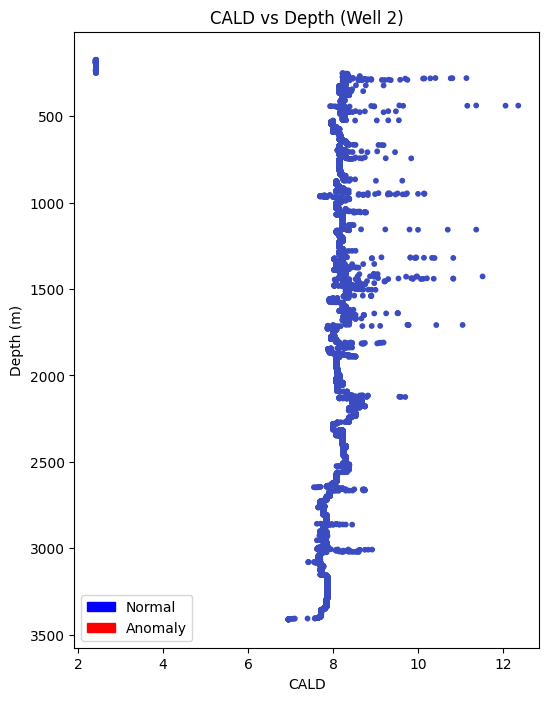

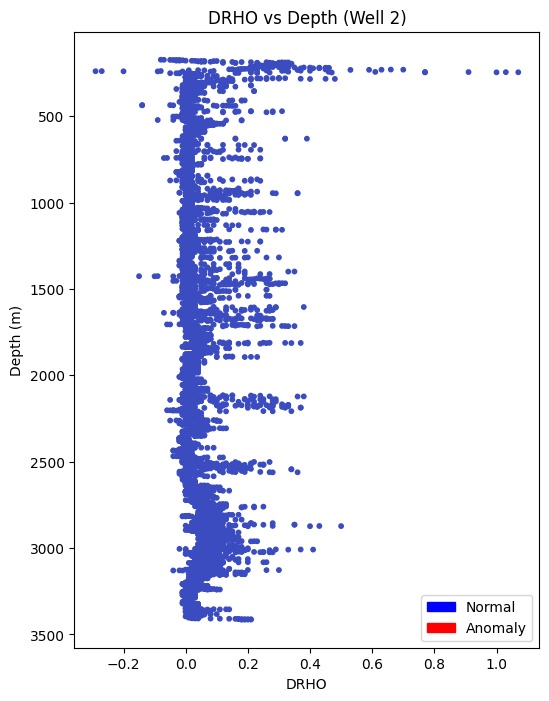

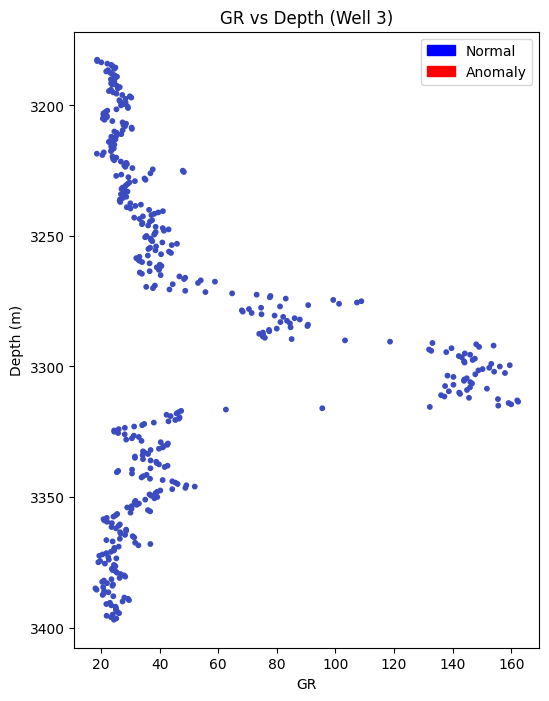

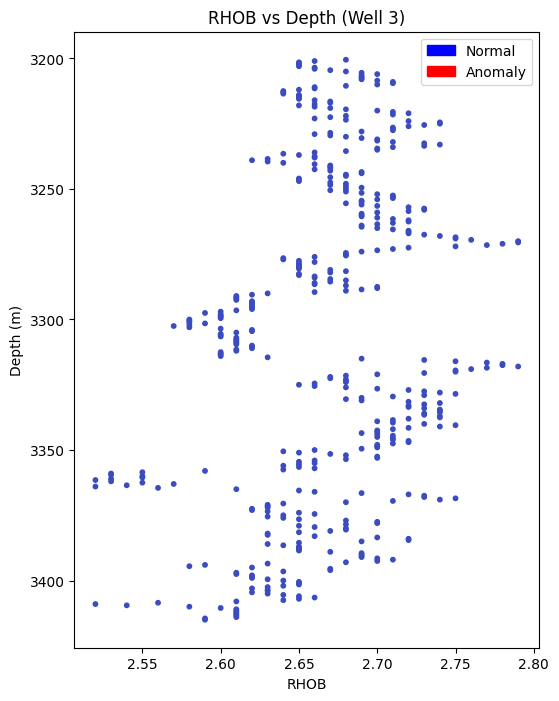

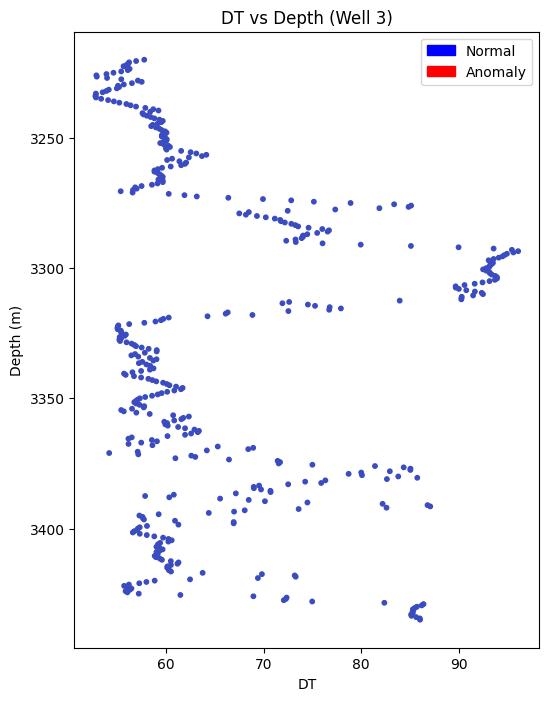

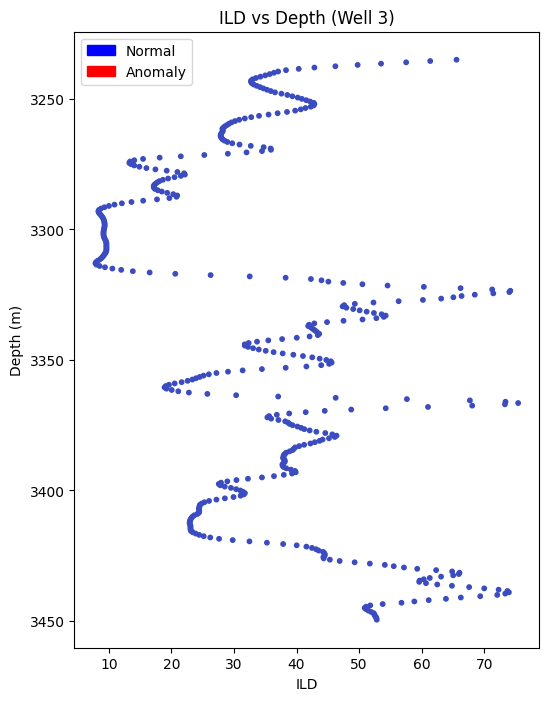

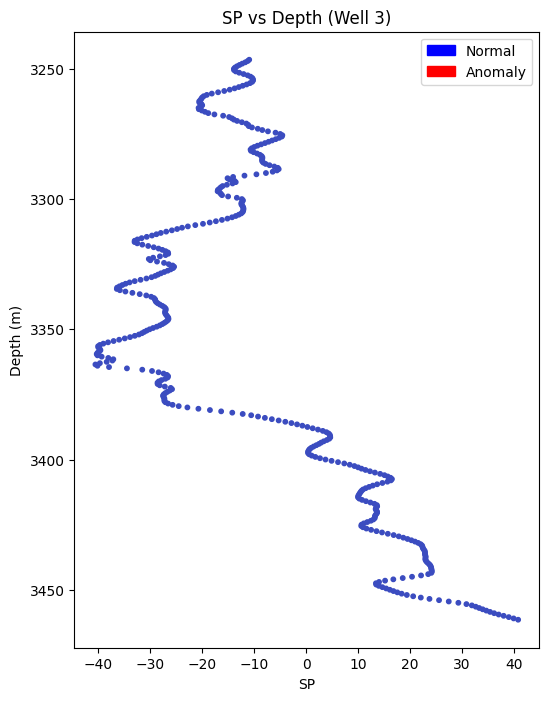

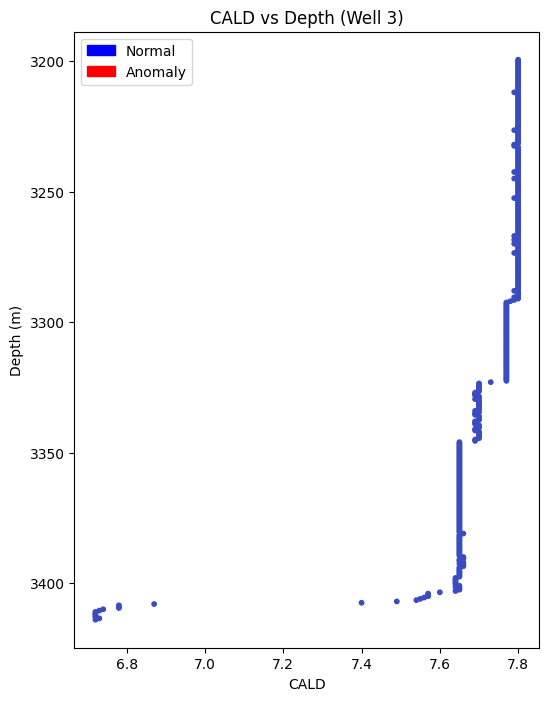

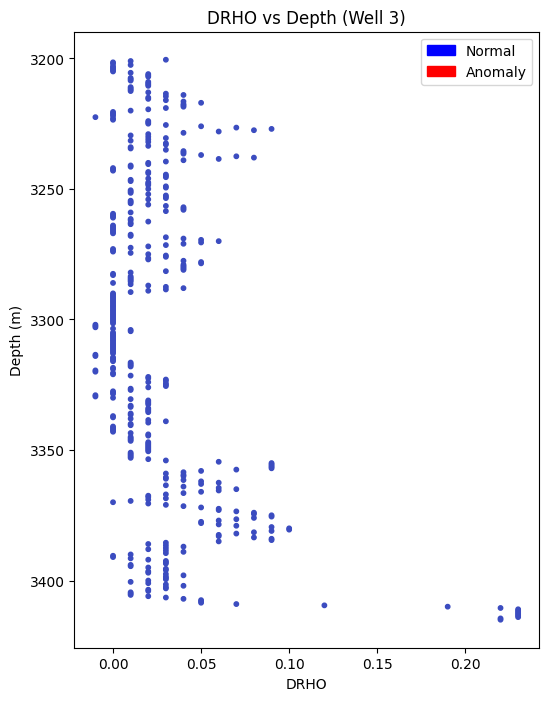

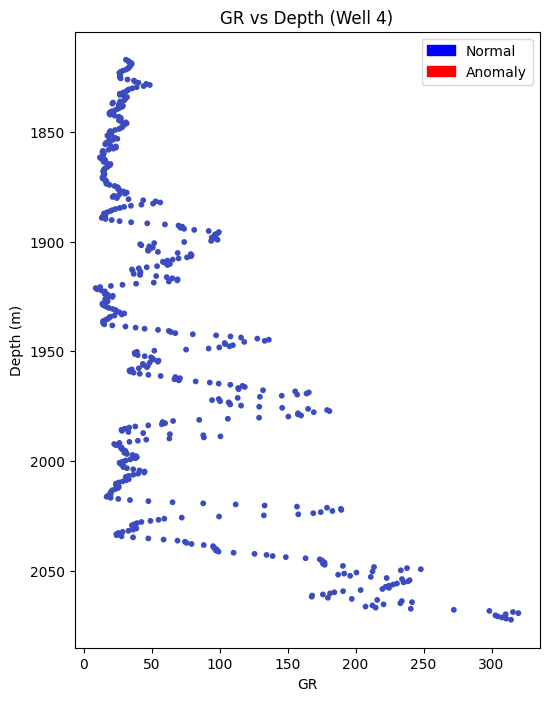

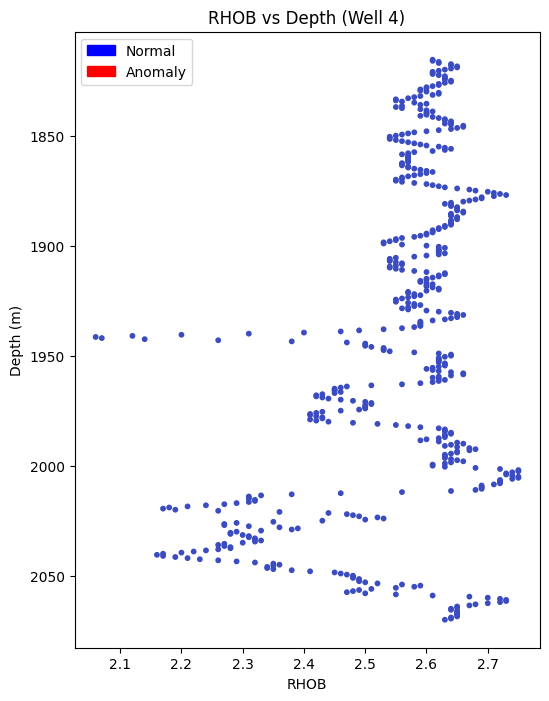

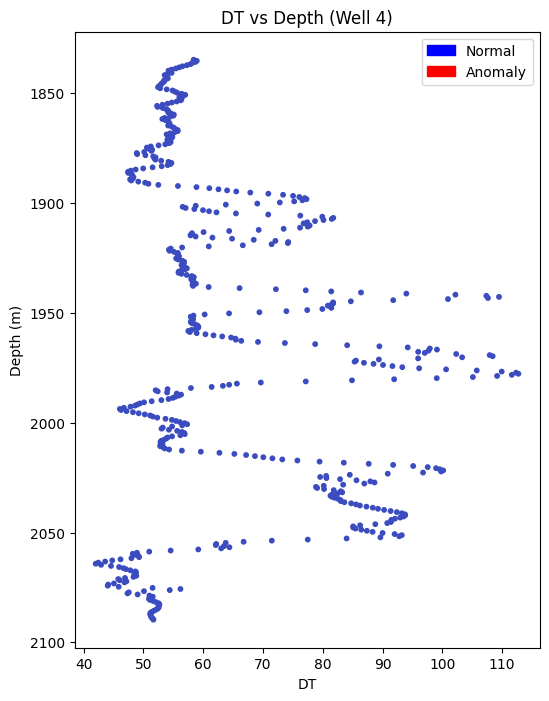

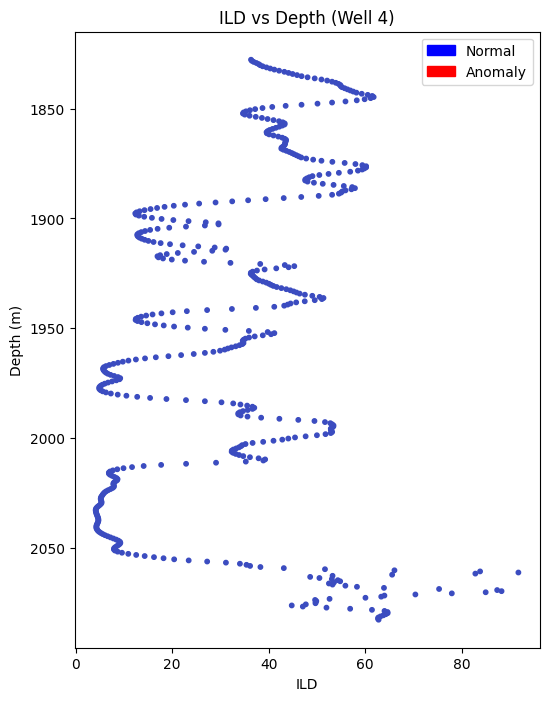

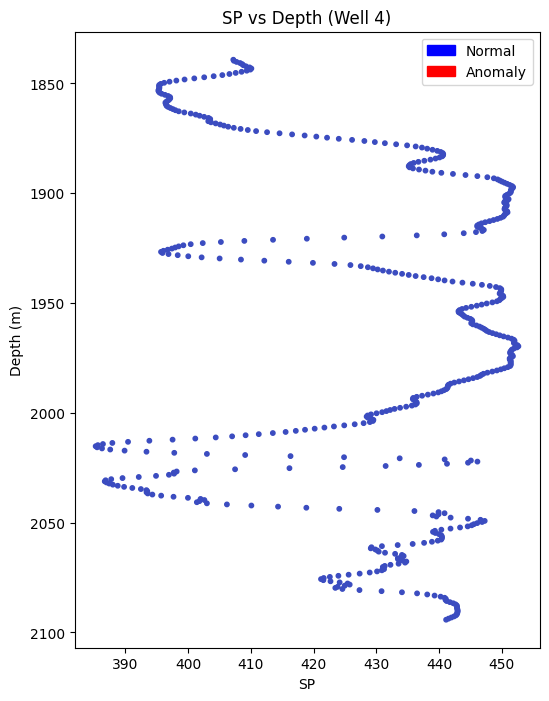

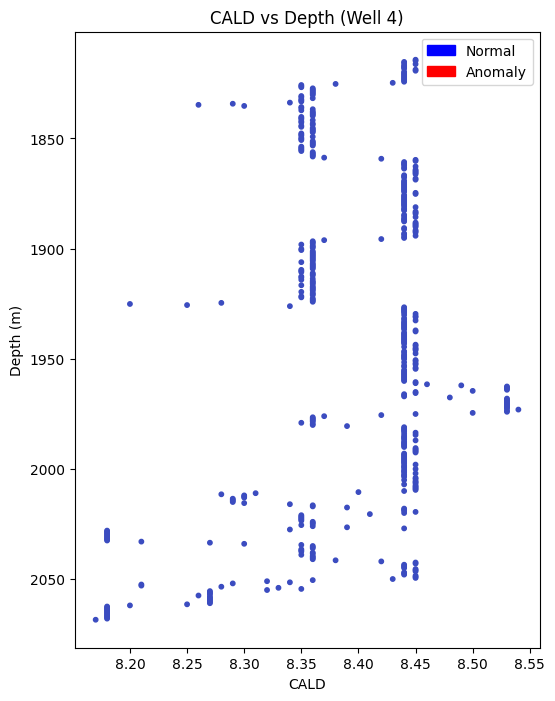

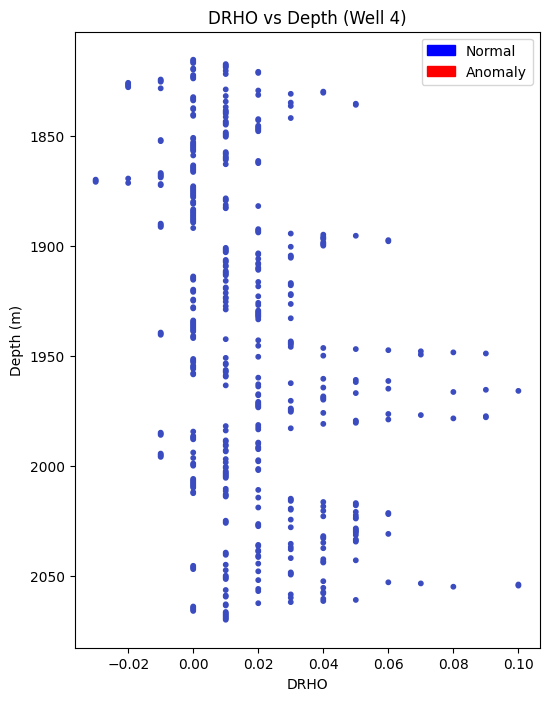

In [ ]:
# ==========================
# 1. Import Libraries
# ==========================
import os
import lasio
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.optimizers import Adam

# ==========================
# 2. Define LAS file paths
# ==========================
las_files = {
    "Well 1": r"C:\Users\LENOVO\Downloads\SASTRA PROJECT\WELL DATA\DATA\File 1.las",
    "Well 2": r"C:\Users\LENOVO\Downloads\SASTRA PROJECT\WELL DATA\DATA\File 2.las",
    "Well 3": r"C:\Users\LENOVO\Downloads\SASTRA PROJECT\WELL DATA\DATA\File 3.las",
    "Well 4": r"C:\Users\LENOVO\Downloads\SASTRA PROJECT\WELL DATA\DATA\File 4.las",
}

# List of features to use
features = ['GR', 'RHOB', 'DT', 'ILD', 'SP', 'CALD', 'DRHO']

# ==========================
# 3. Load LAS files safely
# ==========================
wells = {}

for well_name, file_path in las_files.items():
    las = lasio.read(file_path)
    df = las.df()  # Load log curves
    
    # Reset index to get depth as a column
    df.reset_index(inplace=True)
    df.rename(columns={df.columns[0]: 'DEPT'}, inplace=True)
    
    # Select only available features
    available_features = [f for f in features if f in df.columns]
    missing_features = [f for f in features if f not in df.columns]
    if missing_features:
        print(f"{well_name}: Warning, missing features ignored: {missing_features}")
    
    df_selected = df[['DEPT'] + available_features].copy()
    
    wells[well_name] = df_selected
    
    # Export to CSV
    csv_path = f"{well_name.replace(' ', '_')}_cleaned.csv"
    df_selected.to_csv(csv_path, index=False)
    print(f"{well_name} saved to {csv_path}")

# ==========================
# 4. Scale features
# ==========================
scalers = {}
wells_scaled = {}
for well_name, df in wells.items():
    scaler = MinMaxScaler()
    df_scaled = scaler.fit_transform(df[available_features])
    wells_scaled[well_name] = pd.DataFrame(df_scaled, columns=available_features)
    scalers[well_name] = scaler

# ==========================
# 5. Build Autoencoder Model
# ==========================
input_dim = len(available_features)
input_layer = Input(shape=(input_dim,))
encoded = Dense(64, activation='relu')(input_layer)
encoded = Dense(32, activation='relu')(encoded)
encoded = Dense(16, activation='relu')(encoded)

decoded = Dense(32, activation='relu')(encoded)
decoded = Dense(64, activation='relu')(decoded)
decoded = Dense(input_dim, activation='sigmoid')(decoded)

autoencoder = Model(inputs=input_layer, outputs=decoded)
autoencoder.compile(optimizer=Adam(learning_rate=0.001), loss='mse')

# ==========================
# 6. Train and detect anomalies
# ==========================
reconstruction_errors = {}
autoencoder_anomalies = {}
gr_threshold = 0.6  # Adjust threshold for GR

for well_name, df_scaled in wells_scaled.items():
    autoencoder.fit(df_scaled, df_scaled, epochs=50, batch_size=32, verbose=0)
    reconstructed = autoencoder.predict(df_scaled)
    
    errors = np.mean(np.square(df_scaled - reconstructed), axis=1)
    reconstruction_errors[well_name] = errors
    
    # Flag top 5% errors as anomalies
    error_threshold = np.percentile(errors, 95)
    autoencoder_anomalies[well_name] = errors > error_threshold

# ==========================
# 7. Plot features vs depth with anomalies and legend
# ==========================
for well_name, df in wells.items():
    df_scaled = wells_scaled[well_name]
    
    df['ANOMALY_STAT'] = df['GR'] > gr_threshold if 'GR' in df.columns else False
    df['ANOMALY_AE'] = autoencoder_anomalies[well_name]
    df['ANOMALY_FINAL'] = df['ANOMALY_STAT'] & df['ANOMALY_AE']
    
    for feature in available_features:
        plt.figure(figsize=(6, 8))
        scatter = plt.scatter(df[feature], df['DEPT'], c=df['ANOMALY_FINAL'], 
                              cmap='coolwarm', s=10)
        plt.gca().invert_yaxis()
        plt.title(f"{feature} vs Depth ({well_name})")
        plt.xlabel(feature)
        plt.ylabel("Depth (m)")
        
        # Add legend manually
        import matplotlib.patches as mpatches
        normal_patch = mpatches.Patch(color='blue', label='Normal')
        anomaly_patch = mpatches.Patch(color='red', label='Anomaly')
        plt.legend(handles=[normal_patch, anomaly_patch])
        
        plt.show()
